In [1]:
from DFTStructureGenerator.descriptor import (
    DUPLICATE_CL_IDS,
    build_descriptor_maps,
    dataframe_to_descriptors,
    load_descriptor_maps,
    save_descriptor_maps,
)
import numpy as np
import pandas as pd
from DFTStructureGenerator.Build_DataBase import (
    B_TYPE_ORDER,
    CL_SUBSTRATE_TYPE_ORDER,
    LB_TYPE_ORDER,
    get_boron_type,
    get_cl_substrate_type,
    get_lb_type,
)
from DFTStructureGenerator.project_paths import CSV_DIR, DESCRIPTOR_DIR, FIGURE_DIR, TS_DATA_DIR, repo_path
from DFTStructureGenerator.thermochemistry import apply_qharm_component_energies, database_path, load_reaction_dataset


## Reviewer Run Tags

- `[REVIEWER-RUNNABLE]`: can be run from files included in this repository, such as CSV, descriptor pickle, ASE database, Parquet, or existing figure inputs. No raw Gaussian working directory is required.
- `[RAW-GAUSSIAN/E:/work]`: depends on raw calculation artifacts, Gaussian logs, Mol files, ORCA/Gaussian input-output folders, or the external raw calculation root configured by `BORYLXAT_RAW_CALC_ROOT` (default `E:/work/B_Cl_Nu`). These cells document provenance but are not required for routine review reruns.
- `[OPTIONAL-DESCRIPTOR-GENERATION]`: regenerates descriptors from the released database. Reviewers can skip it and use the pre-extracted descriptor pickle files to save time.


In [2]:
%load_ext autoreload
%autoreload 2


In [3]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold

np.random.seed(0)


In [4]:
from matplotlib import pyplot as plt
from DFTStructureGenerator.draw import (
    draw_correlation_map,
    plot_scatter_with_metrics,
)


In [5]:
duplicate_Cl_id = DUPLICATE_CL_IDS


In [6]:
# Thermochemistry switch: QHARM is the revised default; set False to reproduce the original RRHO analysis.
USE_QHARM = True
DB_PATH = database_path(USE_QHARM)
BARRIER_COLUMN = "deltaGa_qharm(kcal/mol)" if USE_QHARM else "deltaGa(kcal/mol)"
REACTION_ENERGY_COLUMN = "deltaG_qharm(kcal/mol)" if USE_QHARM else "deltaG(kcal/mol)"
BN_CSV_PATH = CSV_DIR / "reactants_B_N.csv"
CL_CSV_PATH = CSV_DIR / "reactants_Cl.csv"

# Descriptor source switch. Use "DFT" for the original descriptors or "xTB" for the cheaper xTB variant.
DESCRIPTOR_VARIANT = "DFT"

DFT_BN_RRHO_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "BNdes_new2.pkl"
DFT_CL_RRHO_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "Cldes_new2.pkl"
DFT_BN_QHARM_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "BNdes_new2_qharm.pkl"
DFT_CL_QHARM_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "Cldes_new2_qharm.pkl"
_qharm_dft_cache_exists = DFT_BN_QHARM_DESCRIPTOR_PATH.exists() and DFT_CL_QHARM_DESCRIPTOR_PATH.exists()
DFT_BN_DESCRIPTOR_PATH = DFT_BN_QHARM_DESCRIPTOR_PATH if USE_QHARM and _qharm_dft_cache_exists else DFT_BN_RRHO_DESCRIPTOR_PATH
DFT_CL_DESCRIPTOR_PATH = DFT_CL_QHARM_DESCRIPTOR_PATH if USE_QHARM and _qharm_dft_cache_exists else DFT_CL_RRHO_DESCRIPTOR_PATH
DFT_BN_REGENERATED_PATH = DFT_BN_QHARM_DESCRIPTOR_PATH if USE_QHARM else DFT_BN_RRHO_DESCRIPTOR_PATH
DFT_CL_REGENERATED_PATH = DFT_CL_QHARM_DESCRIPTOR_PATH if USE_QHARM else DFT_CL_RRHO_DESCRIPTOR_PATH
XTB_BN_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "BNdes_xtb.pkl"
XTB_CL_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "Cldes_xtb.pkl"

_DESCRIPTOR_PATHS = {
    "DFT": (DFT_BN_DESCRIPTOR_PATH, DFT_CL_DESCRIPTOR_PATH),
    "xTB": (XTB_BN_DESCRIPTOR_PATH, XTB_CL_DESCRIPTOR_PATH),
}
if DESCRIPTOR_VARIANT not in _DESCRIPTOR_PATHS:
    raise ValueError(f"DESCRIPTOR_VARIANT must be one of {list(_DESCRIPTOR_PATHS)}, got {DESCRIPTOR_VARIANT!r}")

BN_DESCRIPTOR_PATH, CL_DESCRIPTOR_PATH = _DESCRIPTOR_PATHS[DESCRIPTOR_VARIANT]

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Using {DESCRIPTOR_VARIANT} descriptors")
print("Thermochemistry:", "QHARM" if USE_QHARM else "original RRHO")
print("Target column:", BARRIER_COLUMN)
print("Reaction-energy column:", REACTION_ENERGY_COLUMN)
print("Database:", DB_PATH)
print("BN descriptor path:", BN_DESCRIPTOR_PATH)
print("Cl descriptor path:", CL_DESCRIPTOR_PATH)


Using DFT descriptors
Thermochemistry: QHARM
Target column: deltaGa_qharm(kcal/mol)
Reaction-energy column: deltaG_qharm(kcal/mol)
Database: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\BorylXAT-DB_qh_update.db
BN descriptor path: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Data\descriptor\BNdes_new2_qharm.pkl
Cl descriptor path: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Data\descriptor\Cldes_new2_qharm.pkl


# Descriptor Generation [OPTIONAL-DESCRIPTOR-GENERATION]

Optional provenance/regeneration step. It rebuilds the DFT descriptor pickle files from the selected thermochemistry database. With `USE_QHARM=True`, descriptor entry zero is built from `gibbs_qharm_hartree` and saved to separate `*_qharm.pkl` files. Reviewers can skip these cells and start from **Feature Loading**.

This section writes `BNdes_new2_qharm.pkl`/`Cldes_new2_qharm.pkl` in QHARM mode and the historical `BNdes_new2.pkl`/`Cldes_new2.pkl` in RRHO mode. The xTB descriptor files are generated separately by `revision_xtb_export_descriptor_structures.ipynb`.


In [ ]:
B_N_des_map, Cl_des_map = build_descriptor_maps(
    db_path=DB_PATH,
    bn_csv_path=BN_CSV_PATH,
    cl_csv_path=CL_CSV_PATH,
    duplicate_cl_ids=duplicate_Cl_id,
    use_qharm=USE_QHARM,
    # load_bn_cl_map = [DFT_BN_RRHO_DESCRIPTOR_PATH, DFT_CL_RRHO_DESCRIPTOR_PATH],
)


In [ ]:
save_descriptor_maps(
    B_N_des_map,
    Cl_des_map,
    bn_path=DFT_BN_REGENERATED_PATH,
    cl_path=DFT_CL_REGENERATED_PATH,
)
print("Saved regenerated DFT descriptors:")
print(" ", DFT_BN_REGENERATED_PATH)
print(" ", DFT_CL_REGENERATED_PATH)


  0%|          | 0/181 [37:28<?, ?it/s]

Saved regenerated DFT descriptors:
  D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Data\descriptor\BNdes_new2_qharm.pkl
  D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Data\descriptor\Cldes_new2_qharm.pkl


# Feature Loading [REVIEWER-RUNNABLE]

Loads the descriptor pickle files selected by `DESCRIPTOR_VARIANT`:

- `"DFT"`: original DFT descriptors, `Data/descriptor/BNdes_new2.pkl` and `Data/descriptor/Cldes_new2.pkl`
- `"xTB"`: cheaper xTB descriptors, `Data/descriptor/BNdes_xtb.pkl` and `Data/descriptor/Cldes_xtb.pkl`

For xTB, generate the pickle files first with `revision_xtb_export_descriptor_structures.ipynb`.


In [7]:
missing_descriptor_paths = [
    path for path in [BN_DESCRIPTOR_PATH, CL_DESCRIPTOR_PATH]
    if not path.exists()
]
if missing_descriptor_paths:
    missing_text = "\n".join(str(path) for path in missing_descriptor_paths)
    raise FileNotFoundError(
        f"Missing {DESCRIPTOR_VARIANT} descriptor pickle file(s):\n{missing_text}\n"
        "For xTB descriptors, run revision_xtb_export_descriptor_structures.ipynb after xTB jobs finish."
    )

B_N_des_map, Cl_des_map = load_descriptor_maps(
    bn_path=BN_DESCRIPTOR_PATH,
    cl_path=CL_DESCRIPTOR_PATH,
)
B_N_des_map, Cl_des_map = apply_qharm_component_energies(
    B_N_des_map, Cl_des_map, use_qharm=USE_QHARM, db_path=DB_PATH
)

bn_descriptor_length = len(next(iter(B_N_des_map.values()))) if B_N_des_map else 0
cl_descriptor_length = len(next(iter(Cl_des_map.values()))) if Cl_des_map else 0
print(f"Loaded {DESCRIPTOR_VARIANT} descriptors")
print(f"BN entries: {len(B_N_des_map)}; descriptor length: {bn_descriptor_length}")
print(f"Cl entries: {len(Cl_des_map)}; descriptor length: {cl_descriptor_length}")


Loaded DFT descriptors
BN entries: 20010; descriptor length: 10
Cl entries: 179; descriptor length: 9


# Training Model [REVIEWER-RUNNABLE]

Builds the CatBoost feature matrix from released descriptors and the released reaction CSV.


In [ ]:
# Combined quantitative features used by the CatBoost barrier model.
data_csv = load_reaction_dataset(
    TS_DATA_DIR / "Borane_all.csv", use_qharm=USE_QHARM, db_path=DB_PATH
)
y = data_csv[BARRIER_COLUMN].to_numpy()
all_X = dataframe_to_descriptors(
    data_csv,
    B_N_des_map,
    Cl_des_map,
    duplicate_cl_ids=duplicate_Cl_id,
    reaction_energy_column=REACTION_ENERGY_COLUMN,
)

print(f"Feature matrix built from {DESCRIPTOR_VARIANT} descriptors: {all_X.shape}")


100%|██████████| 8980/8980 [00:01<00:00, 7272.40it/s] 

Feature matrix built from DFT descriptors: (8980, 18)


# Descriptor Correlation [REVIEWER-RUNNABLE]

Uses the loaded descriptors and target values only.


Max correlation:  0.8940046654588573


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,0.717847,0.468165,0.376998,0.297095,0.246473,0.045943,0.046173,0.055464,0.414542,0.020233,0.002905,0.113557,0.083587,0.089210,0.145745,0.257595,0.004970,0.142387
1,0.468165,0.405017,0.856848,0.679059,0.221233,0.272367,0.279494,0.080446,0.655910,0.089166,0.215387,0.222432,0.070387,0.363676,0.107848,0.169905,0.251687,0.142543
2,0.376998,0.856848,0.329403,0.659118,0.247656,0.645200,0.092143,0.042785,0.625334,0.157467,0.211019,0.203633,0.080411,0.339251,0.121176,0.176468,0.227248,0.142926
3,0.297095,0.679059,0.659118,0.239422,0.082895,0.184804,0.454287,0.185153,0.408686,0.224619,0.198707,0.152810,0.119550,0.238820,0.039353,0.042455,0.196037,0.139527
4,0.246473,0.221233,0.247656,0.082895,0.216245,0.016170,0.655525,0.659507,0.674736,0.213584,0.135530,0.204140,0.011633,0.317311,0.116706,0.219034,0.211843,0.100087
5,0.045943,0.272367,0.645200,0.184804,0.016170,0.072364,0.126583,0.006837,0.091266,0.074029,0.039812,0.045326,0.012569,0.062603,0.092475,0.100497,0.018298,0.003398
6,0.046173,0.279494,0.092143,0.454287,0.655525,0.126583,0.017571,0.739104,0.244131,0.046052,0.002215,0.049807,0.049875,0.075143,0.077424,0.092893,0.063364,0.023817
7,0.055464,0.080446,0.042785,0.185153,0.659507,0.006837,0.739104,0.057004,0.389612,0.256209,0.073740,0.087087,0.015220,0.121730,0.055902,0.075688,0.098038,0.063721
8,0.414542,0.655910,0.625334,0.408686,0.674736,0.091266,0.244131,0.389612,0.295408,0.117708,0.290933,0.286064,0.098503,0.475064,0.168630,0.248917,0.324694,0.203393
9,0.020233,0.089166,0.157467,0.224619,0.213584,0.074029,0.046052,0.256209,0.117708,0.079906,0.023238,0.019507,0.030253,0.000772,0.054650,0.024541,0.003738,0.010237


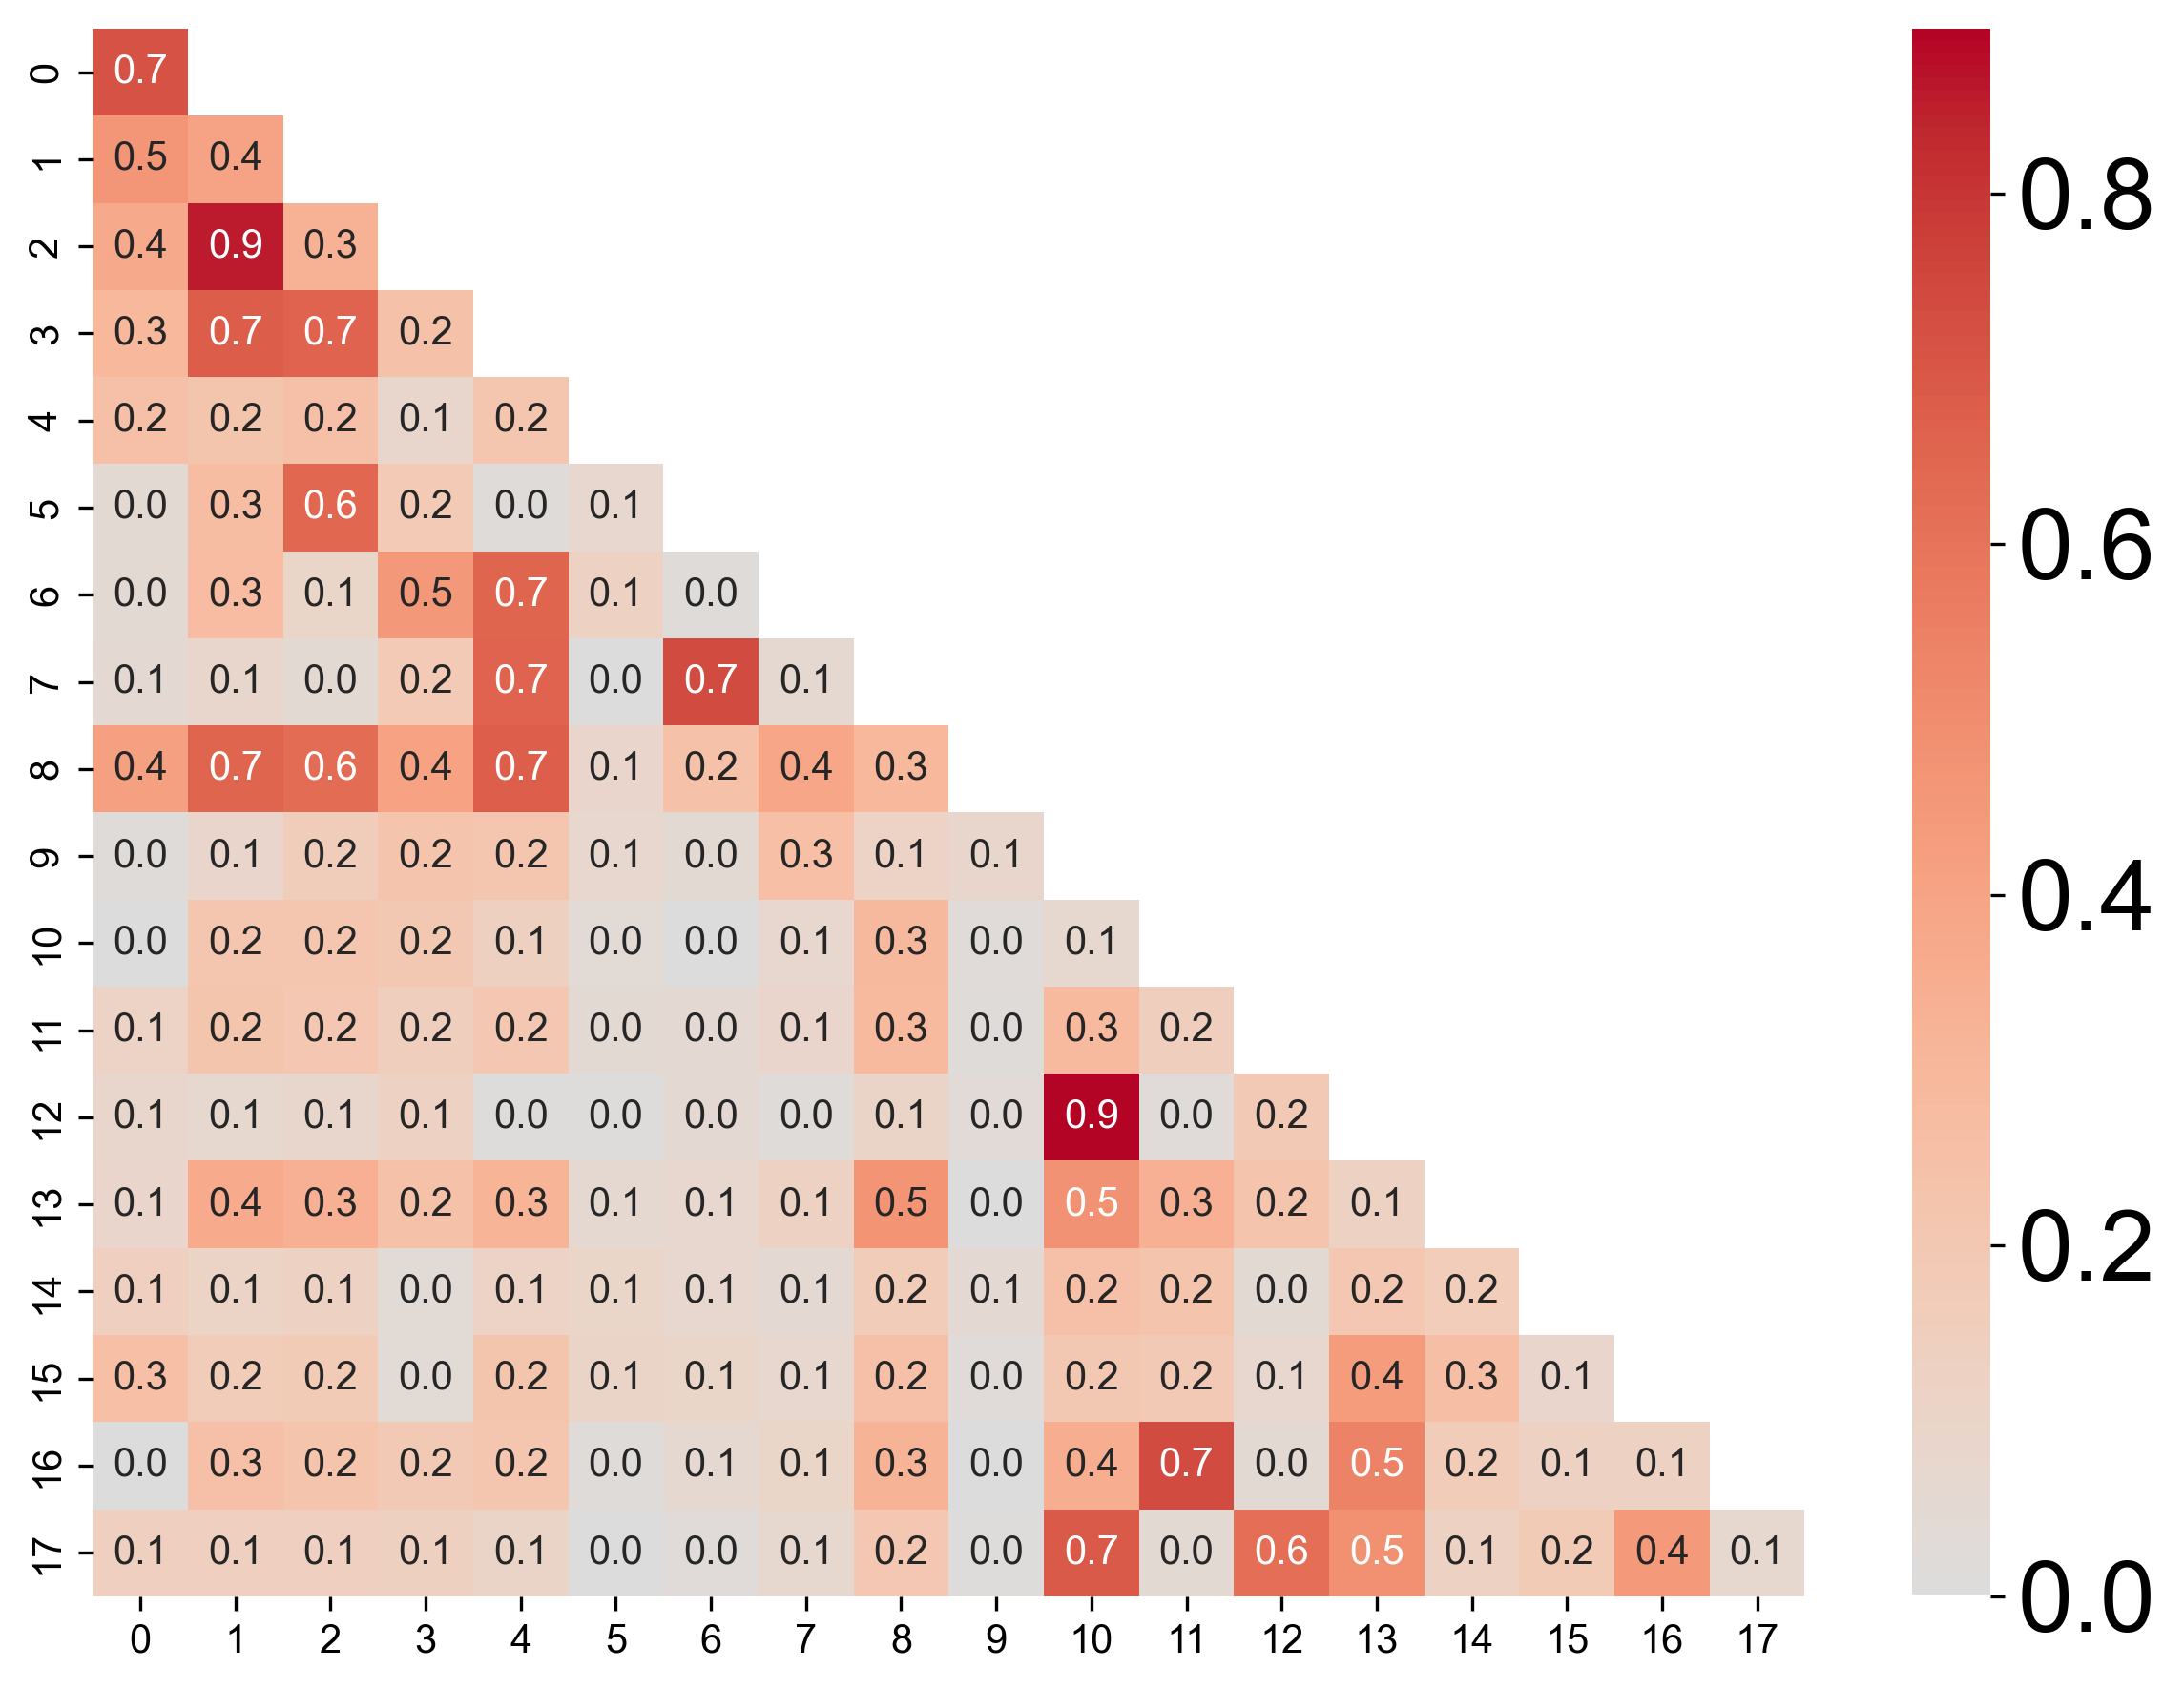

In [43]:
# Figure S21
descriptor_correlation_matrix = draw_correlation_map(
    all_X,
    figure_size=(8, 6),
    colors="coolwarm",
    annot=True,
    show_label=True,
    target=y,
)
plt.savefig(FIGURE_DIR / "FigureS21_descriptor_correlation_map.png", dpi=300, bbox_inches="tight")
descriptor_correlation_matrix


# 5-Fold Validation [REVIEWER-RUNNABLE]

Runs the reported random five-fold CatBoost validation from released descriptors.


In [44]:
kf = KFold(n_splits=5, shuffle=True, random_state=0)
all_r2s = []
all_pred = np.zeros_like(y, dtype=float)

for train_ids, test_ids in kf.split(all_X):
    model = CatBoostRegressor(
        iterations=10000,
        learning_rate=0.01,
        depth=6,
        verbose=0,
        random_state=0,
    )
    model.fit(all_X[train_ids], y[train_ids])
    y_pred = model.predict(all_X[test_ids])

    fold_r2 = r2_score(y[test_ids], y_pred)
    fold_mae = mean_absolute_error(y[test_ids], y_pred)
    fold_mse = mean_squared_error(y[test_ids], y_pred)
    print(f"R2: {fold_r2:.3f}, MAE: {fold_mae:.3f}, MSE: {fold_mse:.3f}")

    all_r2s.append(fold_r2)
    all_pred[test_ids] = y_pred

print(f"Mean of 5-Fold R2: {np.mean(all_r2s):.3f}")
print(f"Mean of 5-Fold MAE: {np.mean([mean_absolute_error(y[test_ids], all_pred[test_ids]) for train_ids, test_ids in kf.split(all_X)]):.3f}")


R2: 0.880, MAE: 1.262, MSE: 2.913
R2: 0.864, MAE: 1.340, MSE: 3.507
R2: 0.896, MAE: 1.176, MSE: 2.611
R2: 0.882, MAE: 1.245, MSE: 3.009
R2: 0.881, MAE: 1.278, MSE: 3.091
Mean of 5-Fold R2: 0.880
Mean of 5-Fold MAE: 1.260


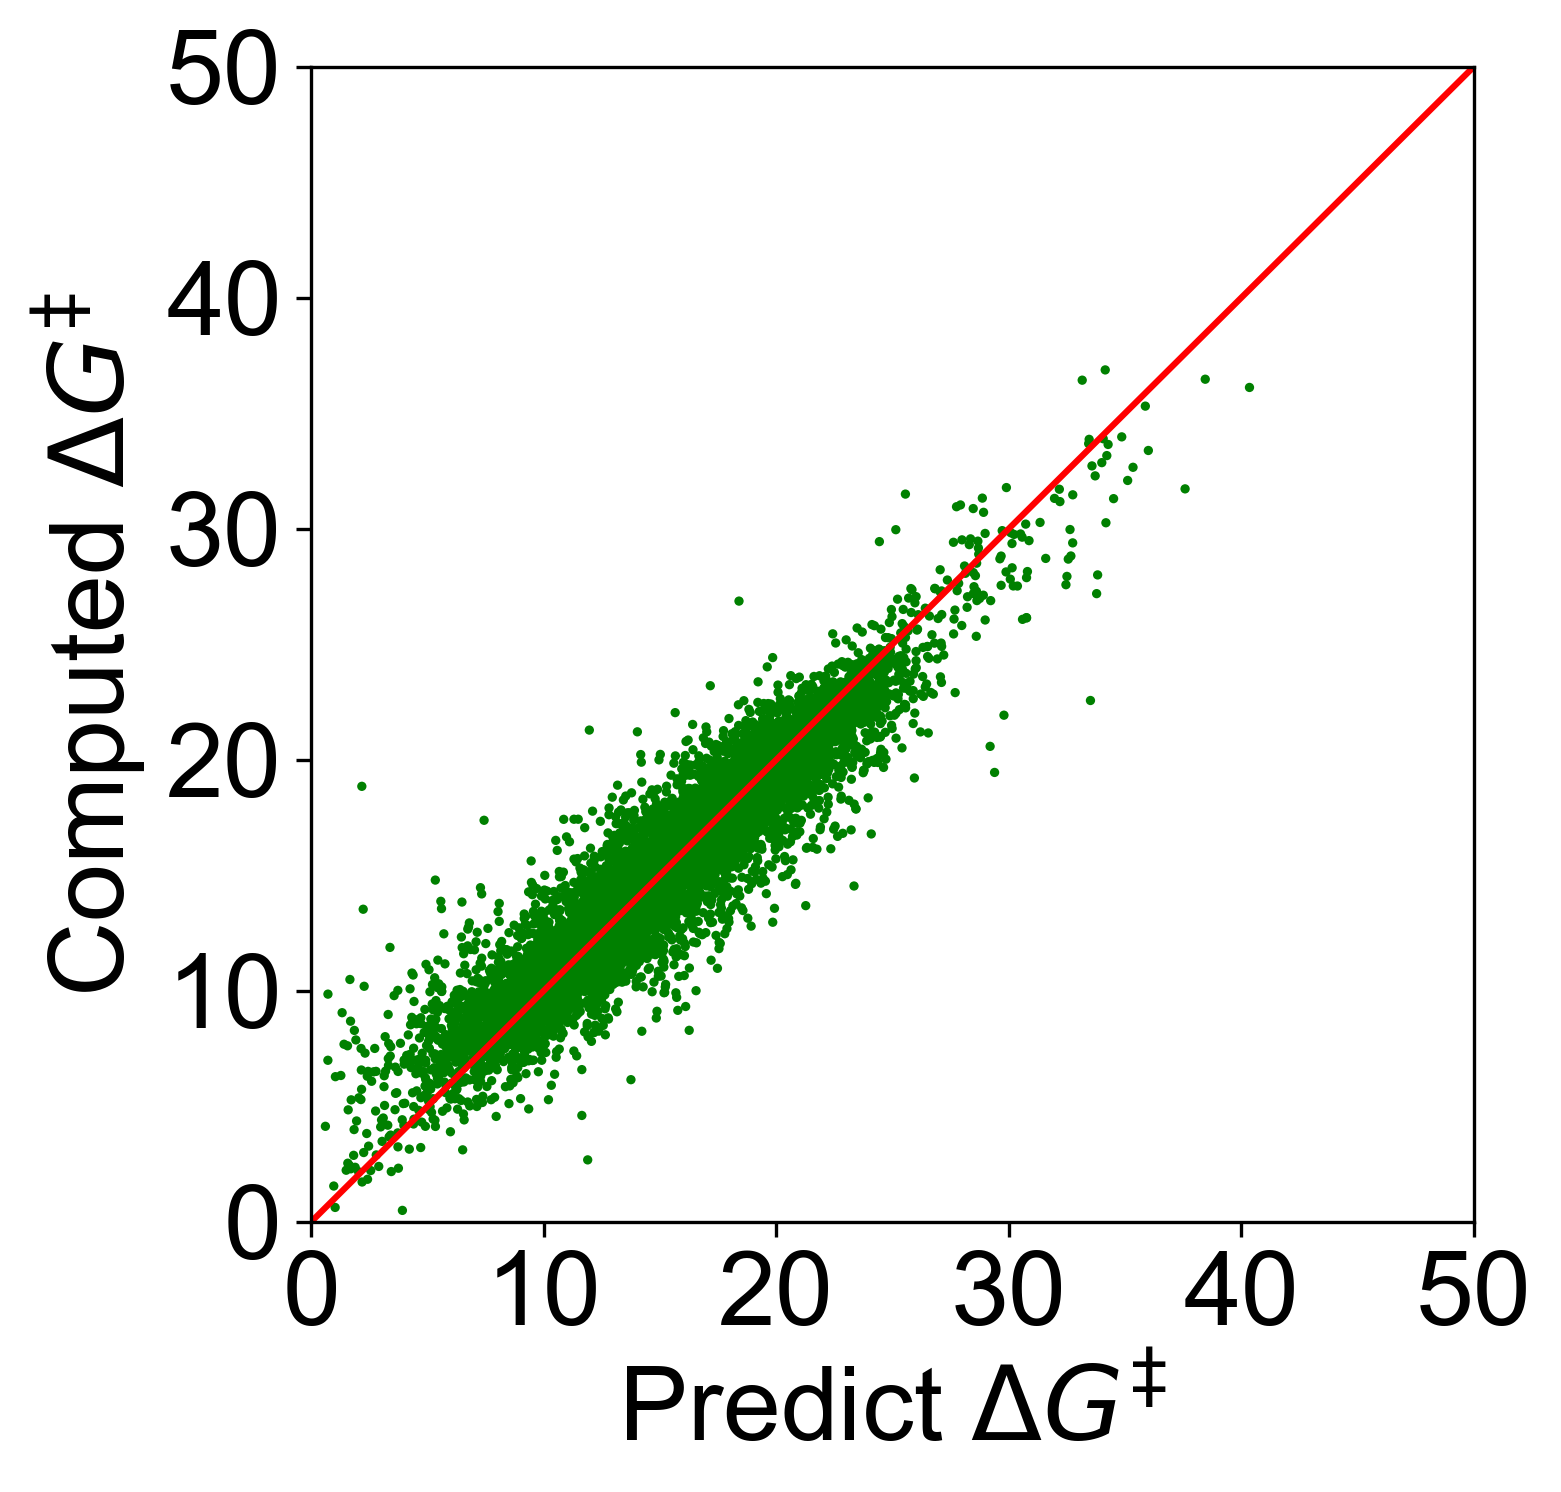

In [45]:
# Figure 6B
plot_scatter_with_metrics(
    y,
    all_pred,
    min_=0,
    max_=50,
    show=False,
)
plt.savefig(FIGURE_DIR / "Figure6B_model_validation.png", dpi=300, bbox_inches="tight")
plt.show()


In [46]:
model = CatBoostRegressor(
    iterations=10000,
    learning_rate=0.01,
    depth=6,
    verbose=0,
    random_state=0,
)
model.fit(all_X, y)
feature_importances = model.feature_importances_


In [ ]:
des_name_std_sorted = [
    '$\\Delta G_{\\mathrm{rxn}}$',                 # deltaG
    'LB-B· $P^{\\mathrm{spin}}$',                  # B_N B_spin
    'LB-B· $q^{\\mathrm{B}}_{\\mathrm{H}}$',       # B_N B_Hirshfield_charge
    'LB-B· $d_{\\mathrm{LB-B}}$',                  # B_N B_N_dist
    'LB-B· $E_{\\mathrm{SOMO}}$',                  # B_N Alpha-HOMO
    'LB-B-Cl $q^{\\mathrm{B}}_{\\mathrm{H}}$',     # B_N_Cl B_Hirshfield_charge
    'LB-B-Cl $q^{\\mathrm{Cl}}_{\\mathrm{H}}$',    # B_N_Cl Cl_Hirshfield_charge
    'LB-B· $d_{\\mathrm{B-Cl}}$',                  # B_N_Cl N_Cl_dist
    'LB-B-Cl $E_{\\mathrm{LUMO}}$',                # B_N_Cl LUMO
    'LB-B-Cl $\\%V_{\\mathrm{bur}}$',              # B_N_Cl Bv6radius
    'Cl-C $q^{\\mathrm{Cl}}_{\\mathrm{H}}$',       # C_Cl Cl_Hirshfield_charge
    'Cl-C $q^{\\mathrm{C}}_{\\mathrm{H}}$',        # C_Cl C_Hirshfield_charge
    'Cl-C $d_{\\mathrm{Cl-C}}$',                   # C_Cl C_Cl_dist
    'Cl-C $E_{\\mathrm{LUMO}}$',                   # C_Cl LUMO
    'C_Cl $\\%V_{\\mathrm{bur}}$',                 # C_Cl Bv6radius
    'C· $P^{\\mathrm{spin}}$',                     # C C_spin
    'C· $q^{\\mathrm{C}}_{\\mathrm{H}}$',          # C C_Hirshfield_charge
    'C· $E_{\\mathrm{SOMO}}$'                      # C Alpha-HOMO
]

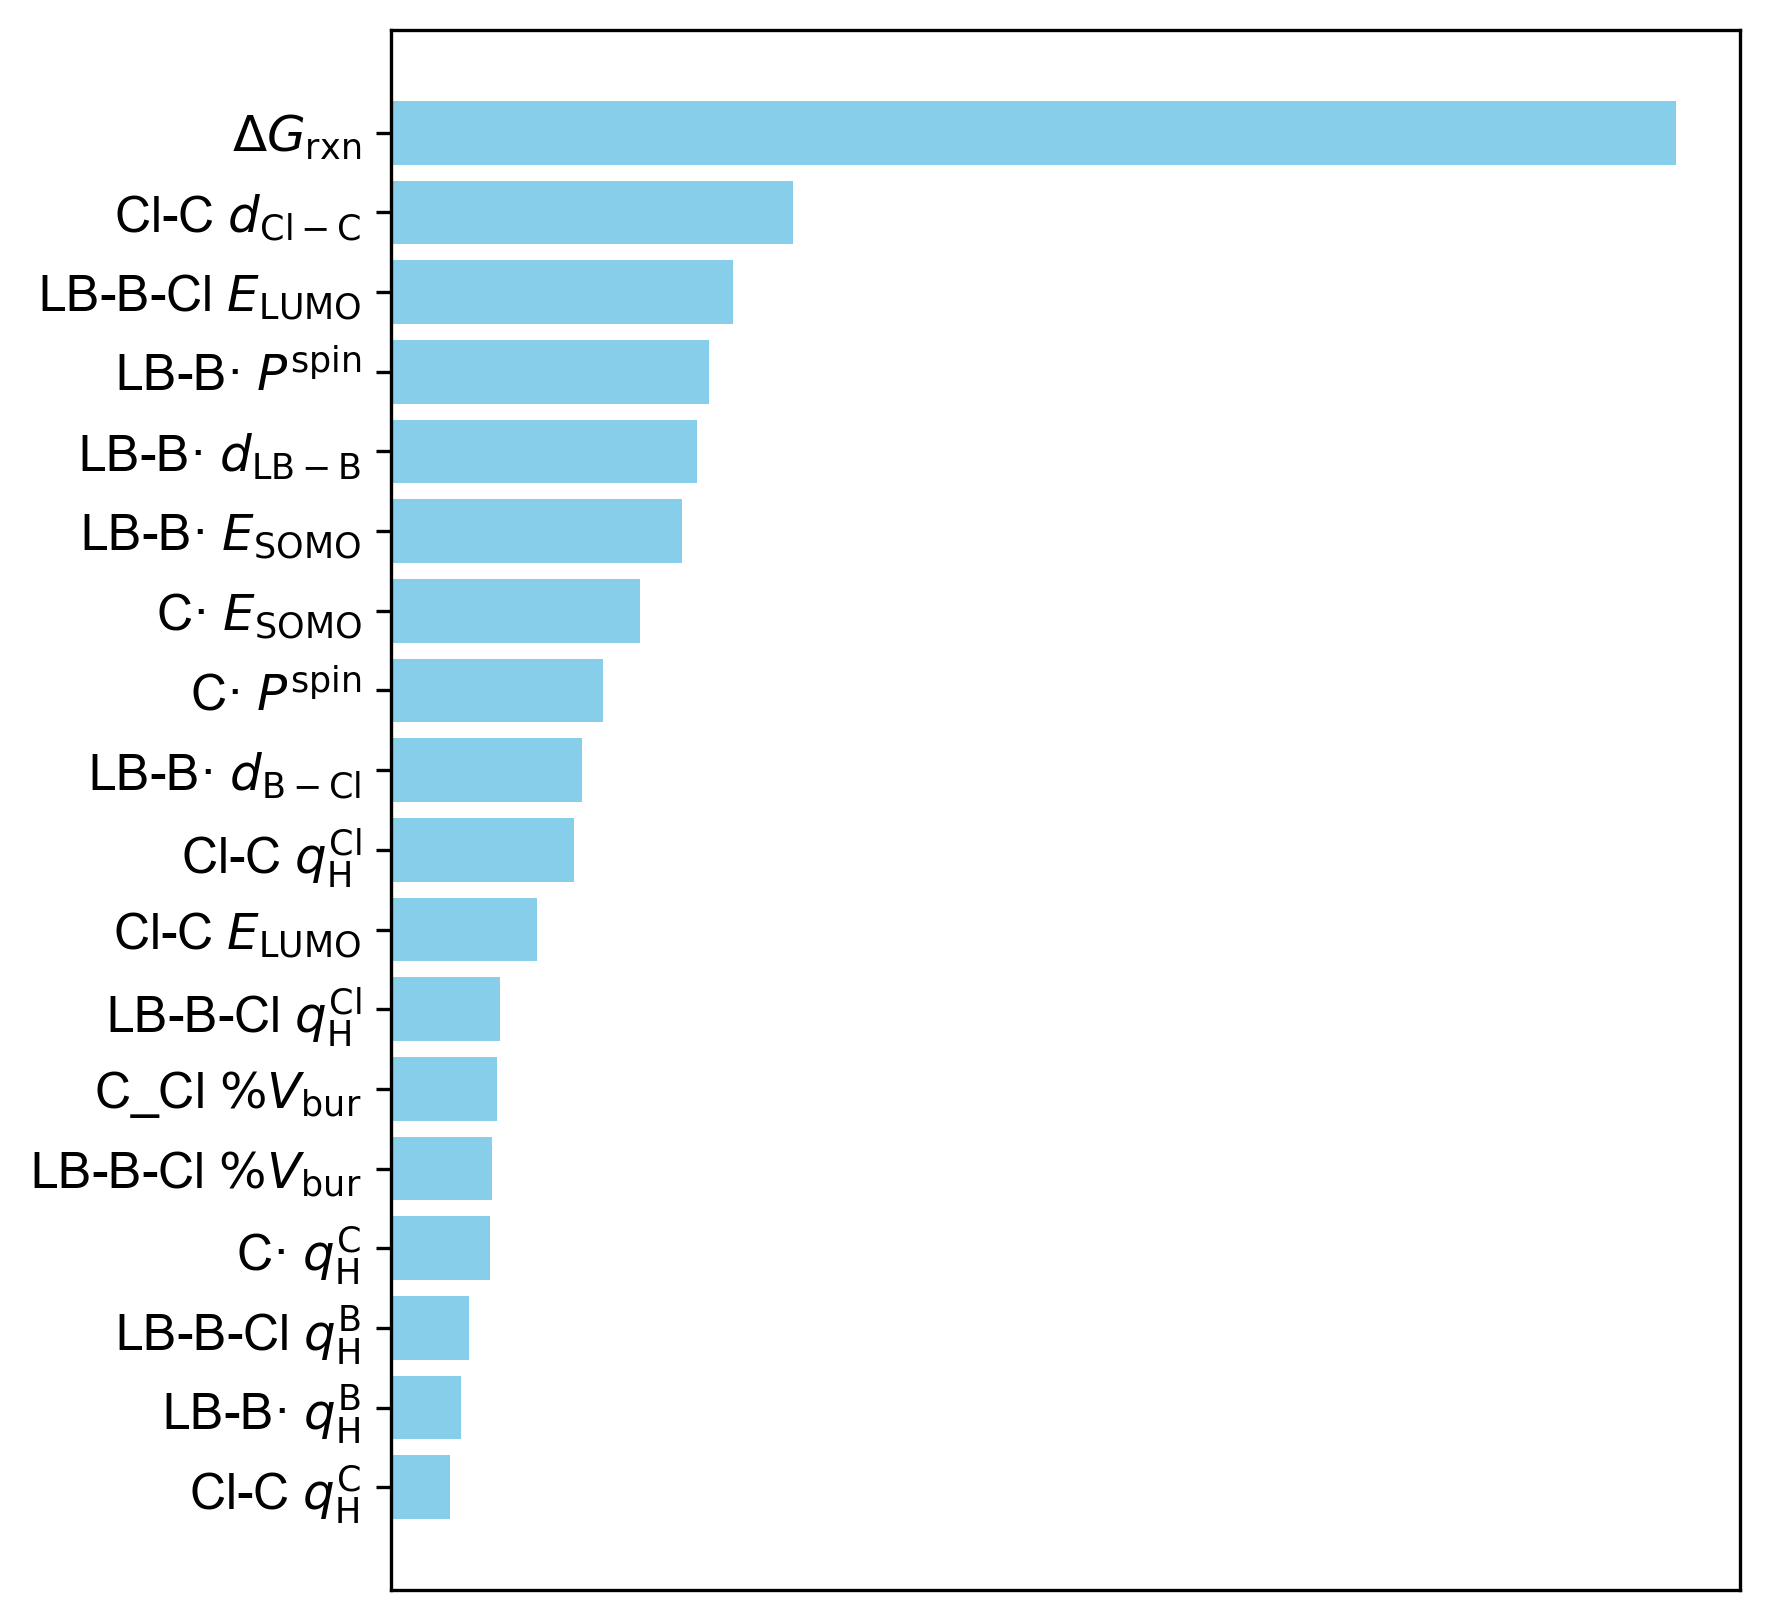

In [48]:
fig, ax = plt.subplots(figsize=(6, 5.5), dpi=300)
plt.rcParams["font.sans-serif"] = "Arial"
feature_order = np.argsort(feature_importances)
ax.barh(
    np.array(des_name_std_sorted)[feature_order],
    feature_importances[feature_order],
    color="skyblue",
)
ax.set_xticks([])
ax.tick_params(axis="y", labelsize=12)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "Figure6C_model_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()


# Other Seeds [REVIEWER-RUNNABLE]

Optional robustness check using different random seeds; it is reviewer-runnable but more time-consuming than the main validation.


In [49]:
y = data_csv[BARRIER_COLUMN].to_numpy()
kf = KFold(n_splits=5, shuffle=True, random_state=1)

for seed in range(10):
    all_r2s, all_mae, all_mse = [], [], []
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    for train_ids, test_ids in list(kf.split(all_X)):
        model = CatBoostRegressor(iterations=10000, learning_rate=0.01, depth=6, verbose=0, random_state=0)
        # model = RandomForestRegressor()
        model.fit(all_X[train_ids], y[train_ids])
        y_pred = model.predict(all_X[test_ids])
        all_r2s.append(r2_score(y[test_ids], y_pred))
        all_mae.append(mean_absolute_error(y[test_ids], y_pred))
        all_mse.append(mean_squared_error(y[test_ids], y_pred))
    print(f"Seed: {seed}, R2: {np.mean(all_r2s):.3f}, MAE: {np.mean(all_mae):.3f}, MSE: {np.mean(all_mse):.3f}")

Seed: 0, R2: 0.880, MAE: 1.260, MSE: 3.026
Seed: 1, R2: 0.878, MAE: 1.267, MSE: 3.070
Seed: 2, R2: 0.880, MAE: 1.261, MSE: 3.034
Seed: 3, R2: 0.879, MAE: 1.262, MSE: 3.060
Seed: 4, R2: 0.881, MAE: 1.259, MSE: 3.009
Seed: 5, R2: 0.880, MAE: 1.256, MSE: 3.024
Seed: 6, R2: 0.881, MAE: 1.258, MSE: 3.009
Seed: 7, R2: 0.880, MAE: 1.262, MSE: 3.030
Seed: 8, R2: 0.881, MAE: 1.264, MSE: 3.017
Seed: 9, R2: 0.882, MAE: 1.247, MSE: 2.979


# OOD [REVIEWER-RUNNABLE]

Optional out-of-distribution validation from released descriptors and reaction metadata.


## OOD around Indexes [REVIEWER-RUNNABLE]

Component-index held-out validation; no raw Gaussian folders are required.


OOD by Cl_Index


,OOD_axis,fold,train_index_count,test_index_count,train_size,test_size,R2,MAE,MSE
0,Cl_Index,1,142,36,7058,1922,0.712459,2.085571,9.262717
1,Cl_Index,2,142,36,7296,1684,0.870709,1.327476,3.151874
2,Cl_Index,3,142,36,7348,1632,0.841384,1.469836,3.610173
3,Cl_Index,4,143,35,7200,1780,0.666673,2.027605,7.374732
4,Cl_Index,5,143,35,7018,1962,0.718015,1.812618,6.523011


Mean fold R2: 0.7618479858110486 MAE: 1.7446211553495297
Overall R2: 0.7581846400672831 MAE: 1.7603788888429432


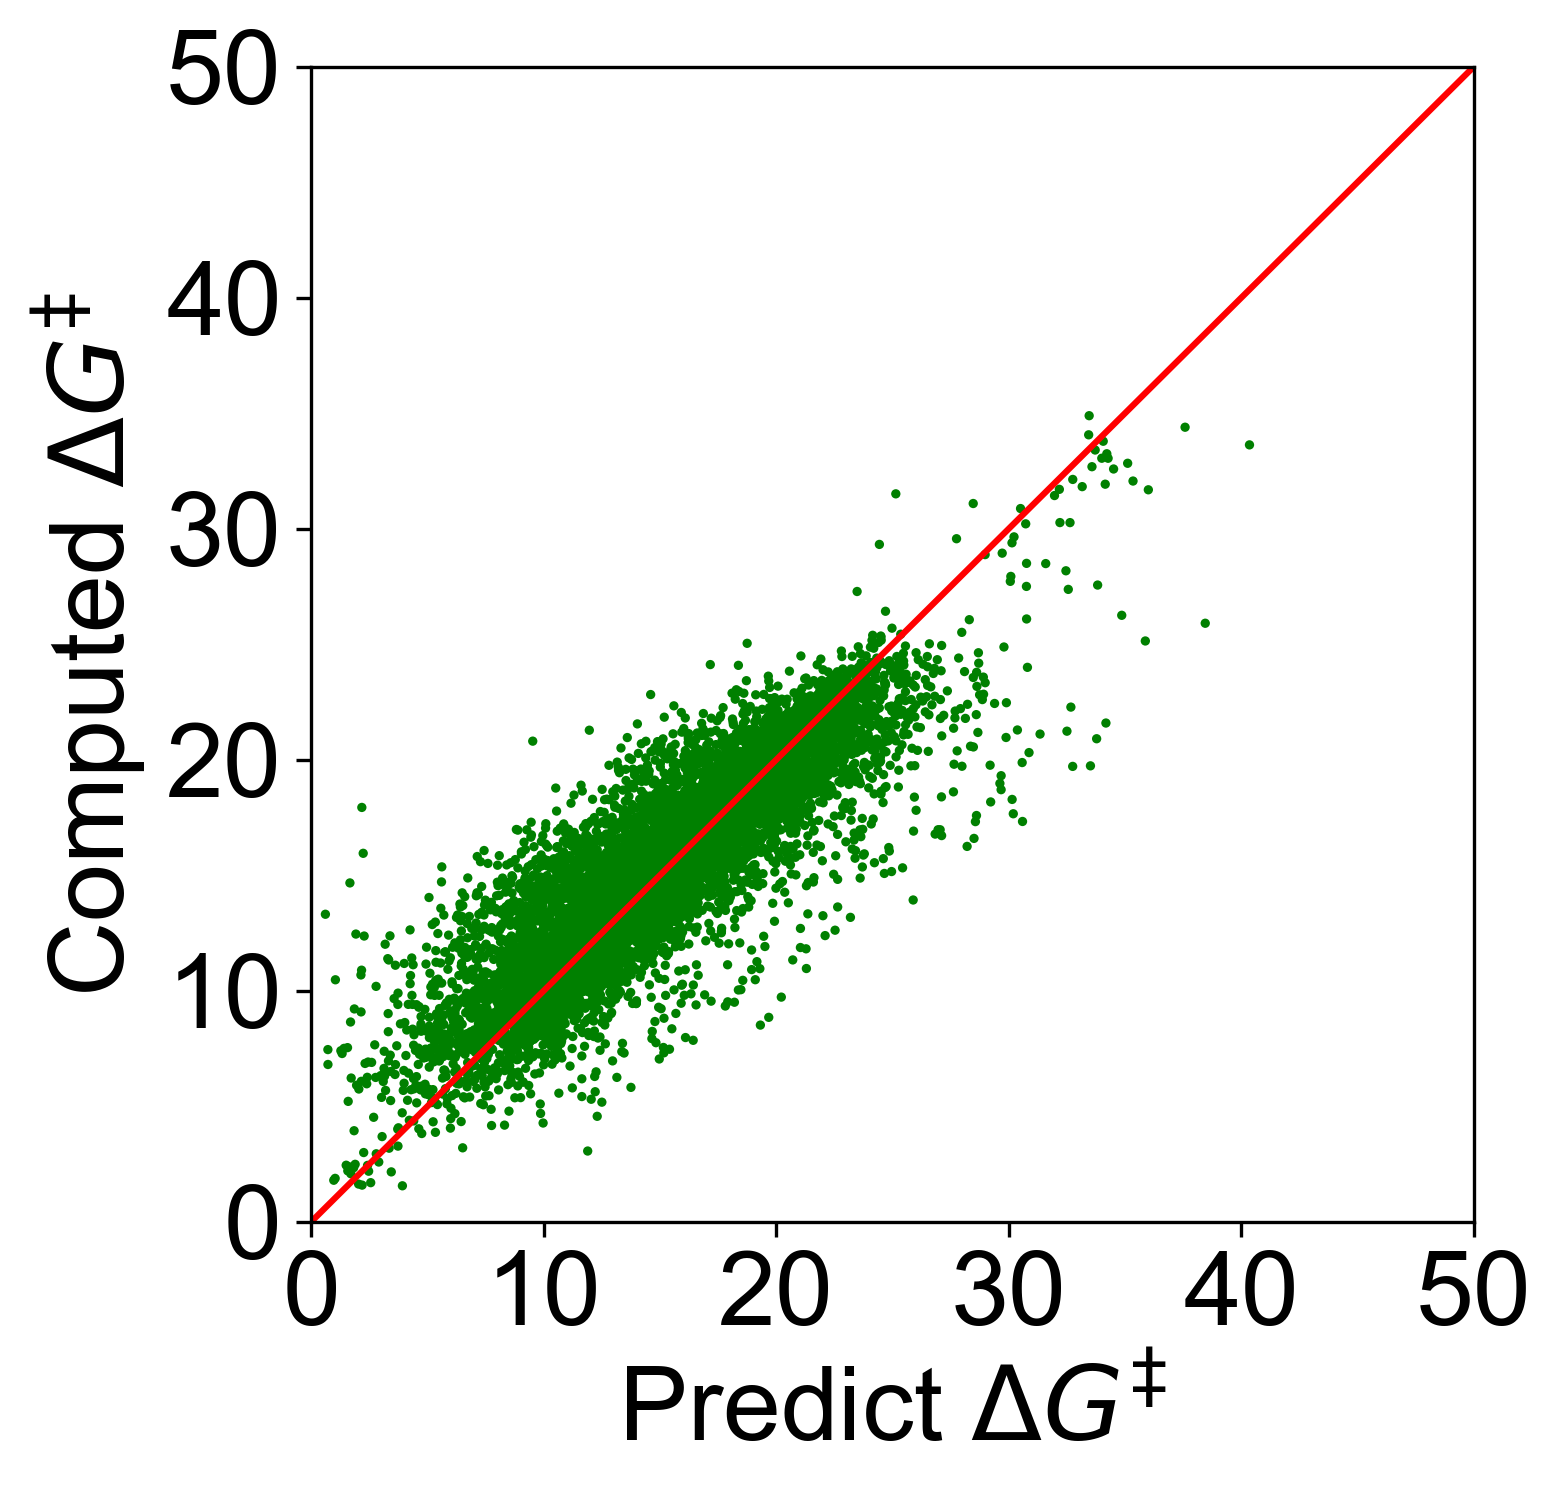

OOD by B_Index


,OOD_axis,fold,train_index_count,test_index_count,train_size,test_size,R2,MAE,MSE
0,B_Index,1,44,11,7638,1342,0.819228,1.618389,4.804138
1,B_Index,2,44,11,7557,1423,0.839402,1.530728,4.271920
2,B_Index,3,44,11,6954,2026,0.843483,1.368792,3.571234
3,B_Index,4,44,11,7220,1760,0.827593,1.500546,4.169550
4,B_Index,5,44,11,6551,2429,0.862334,1.428008,3.624467


Mean fold R2: 0.8384080688810596 MAE: 1.4892925203705087
Overall R2: 0.8419365924691201 MAE: 1.4735933757885176


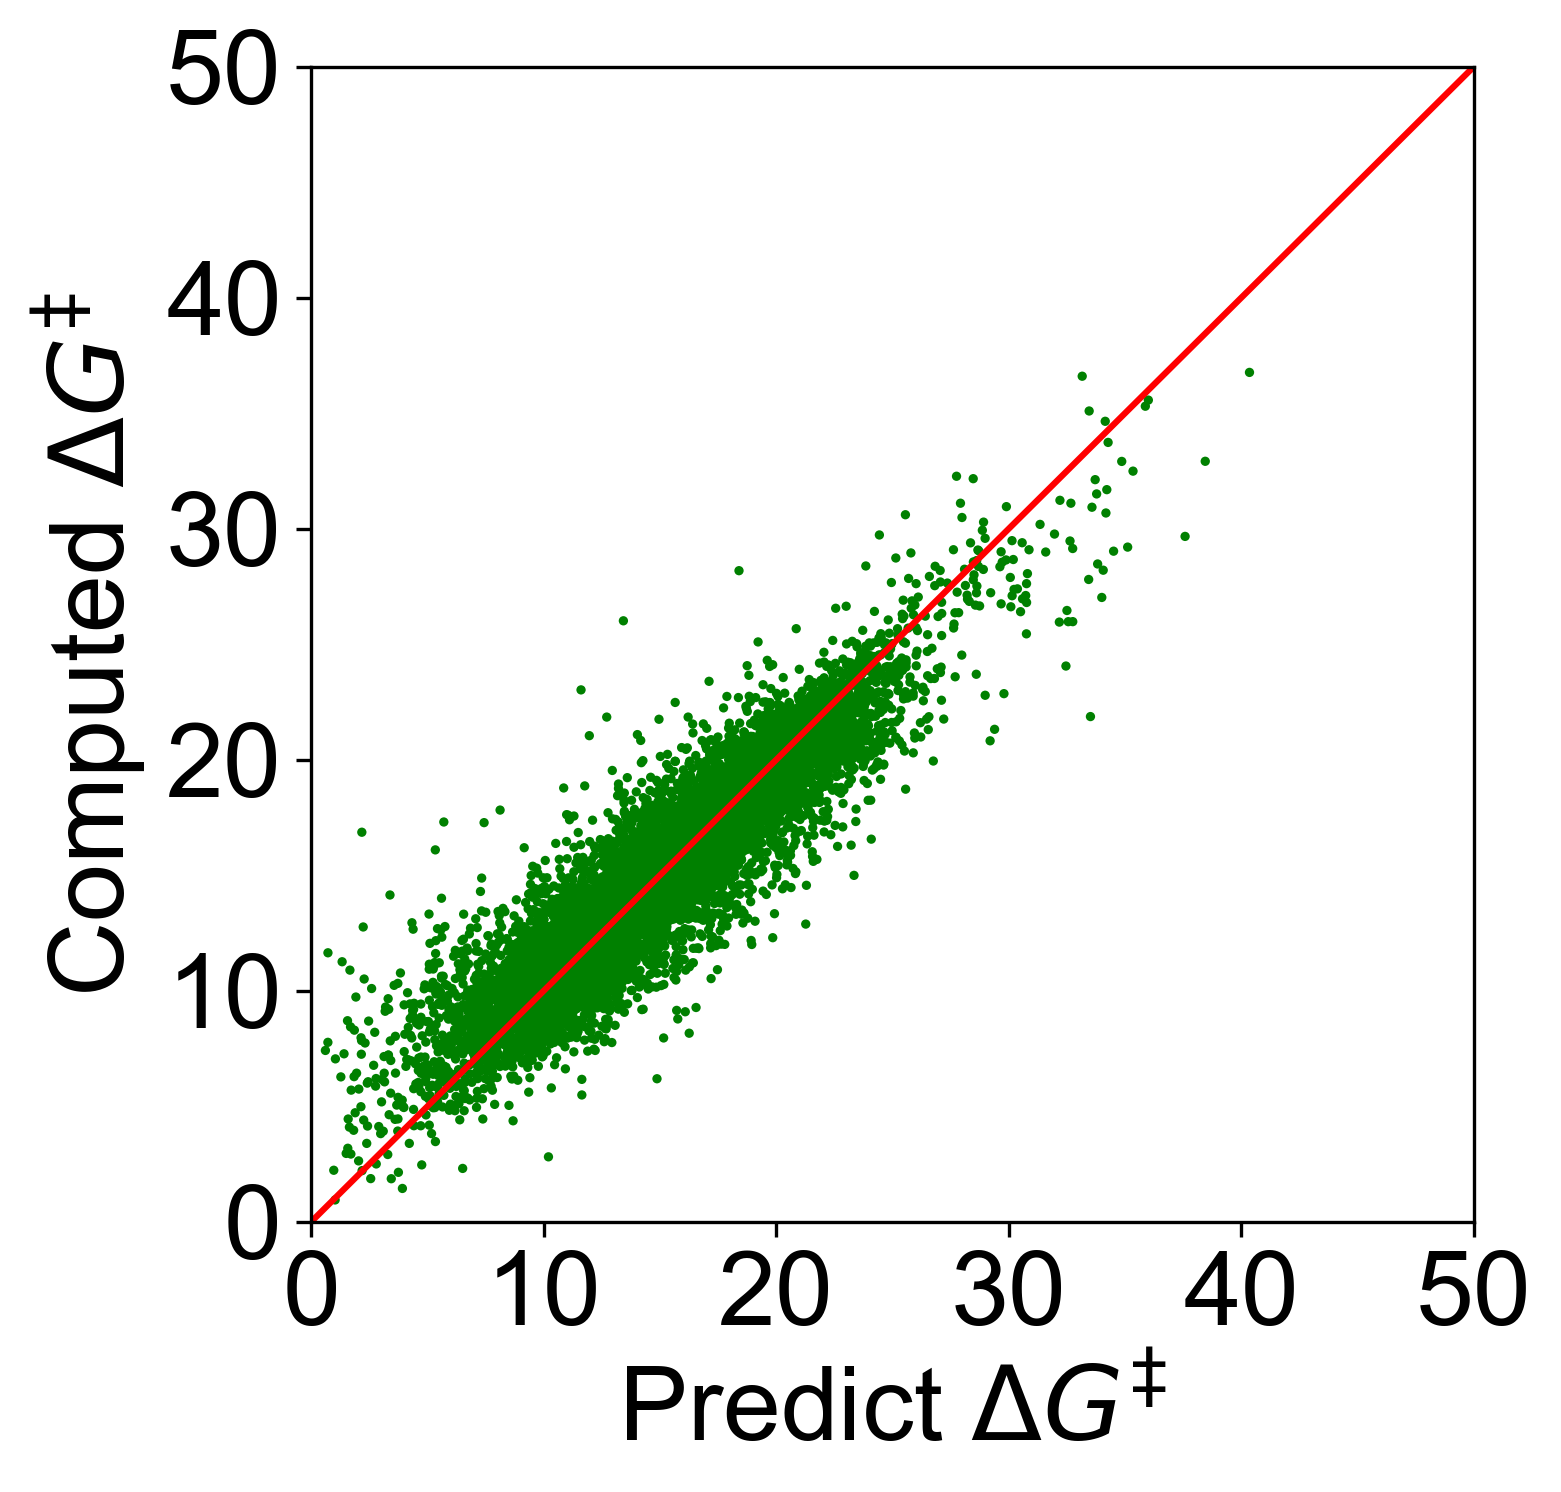

OOD by Nu_Index


,OOD_axis,fold,train_index_count,test_index_count,train_size,test_size,R2,MAE,MSE
0,Nu_Index,1,307,77,6598,2382,0.790527,1.631485,5.643354
1,Nu_Index,2,307,77,7303,1677,0.852535,1.407828,3.581023
2,Nu_Index,3,307,77,7455,1525,0.813281,1.447598,4.550062
3,Nu_Index,4,307,77,7302,1678,0.835729,1.550918,4.586062
4,Nu_Index,5,308,76,7262,1718,0.837394,1.371138,3.502239


Mean fold R2: 0.8258930296482223 MAE: 1.481793140317686
Overall R2: 0.8234670880215644 MAE: 1.4936263980251685


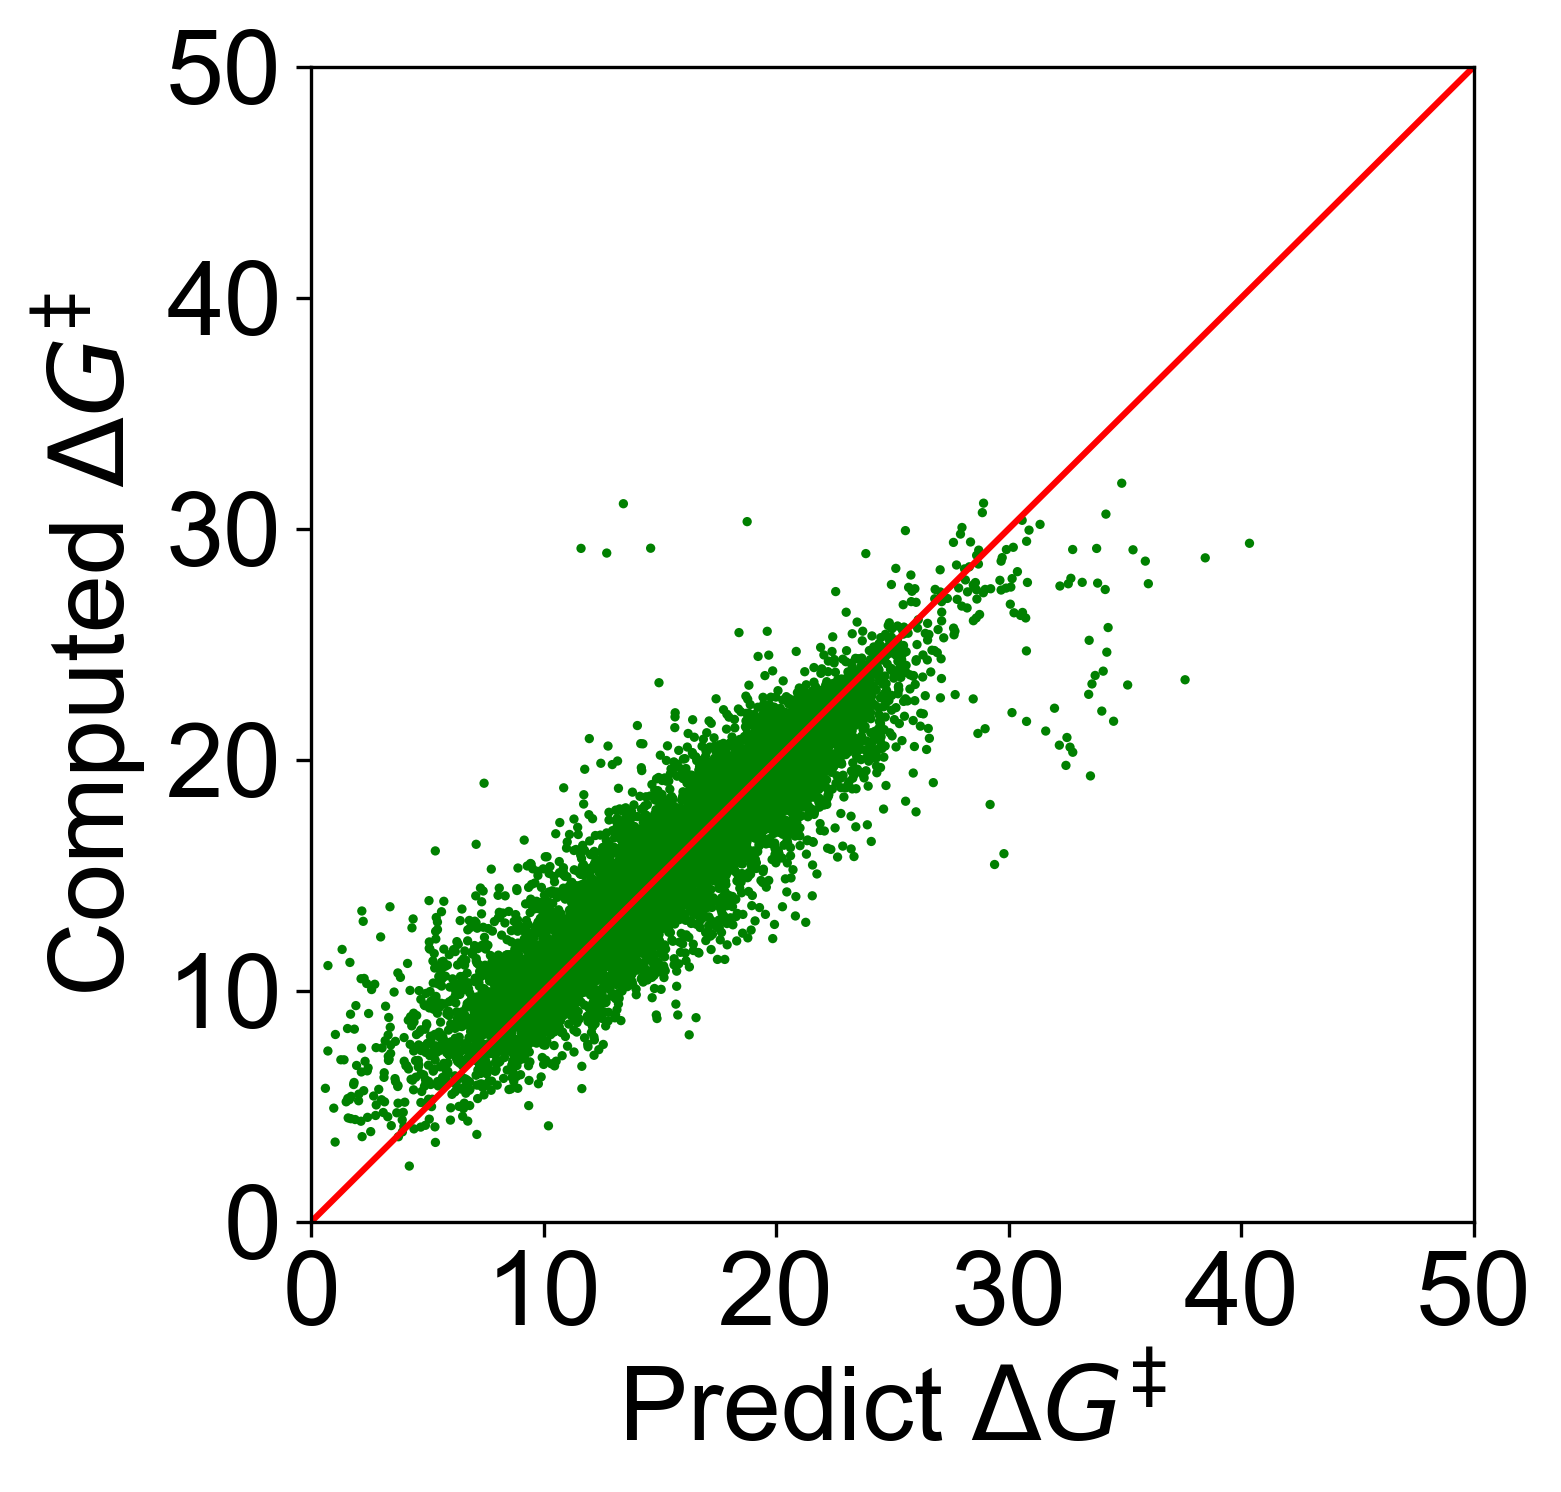

,OOD_axis,fold,train_index_count,test_index_count,train_size,test_size,R2,MAE,MSE
0,Cl_Index,1,142,36,7058,1922,0.712459,2.085571,9.262717
1,Cl_Index,2,142,36,7296,1684,0.870709,1.327476,3.151874
2,Cl_Index,3,142,36,7348,1632,0.841384,1.469836,3.610173
3,Cl_Index,4,143,35,7200,1780,0.666673,2.027605,7.374732
4,Cl_Index,5,143,35,7018,1962,0.718015,1.812618,6.523011
5,B_Index,1,44,11,7638,1342,0.819228,1.618389,4.804138
6,B_Index,2,44,11,7557,1423,0.839402,1.530728,4.271920
7,B_Index,3,44,11,6954,2026,0.843483,1.368792,3.571234
8,B_Index,4,44,11,7220,1760,0.827593,1.500546,4.169550
9,B_Index,5,44,11,6551,2429,0.862334,1.428008,3.624467


In [50]:
def run_index_ood(
    data_df,
    index_column,
    label=None,
    n_splits=5,
    target_column=BARRIER_COLUMN,
    min_test_size=2,
):
    label = label or index_column
    index_values = np.sort(data_df[index_column].dropna().unique())
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)

    result_rows = []
    pred_rows = []
    for fold_id, (train_ids, test_ids) in enumerate(kf.split(index_values), start=1):
        train_values = index_values[train_ids]
        test_values = index_values[test_ids]
        train_df = data_df.loc[data_df[index_column].isin(train_values)].reset_index(drop=True)
        test_df = data_df.loc[data_df[index_column].isin(test_values)].reset_index(drop=True)
        if len(test_df) < min_test_size or len(train_df) == 0:
            continue

        train_X = dataframe_to_descriptors(
            train_df,
            B_N_des_map,
            Cl_des_map,
            duplicate_cl_ids=duplicate_Cl_id,
            show_progress=False,
            reaction_energy_column=REACTION_ENERGY_COLUMN,
        )
        test_X = dataframe_to_descriptors(
            test_df,
            B_N_des_map,
            Cl_des_map,
            duplicate_cl_ids=duplicate_Cl_id,
            show_progress=False,
            reaction_energy_column=REACTION_ENERGY_COLUMN,
        )
        train_y = train_df[target_column]
        test_y = test_df[target_column]

        model = CatBoostRegressor(
            iterations=10000,
            learning_rate=0.01,
            depth=6,
            verbose=0,
            random_state=0,
        )
        model.fit(train_X, train_y)
        y_pred = model.predict(test_X)

        result_rows.append({
            "OOD_axis": label,
            "fold": fold_id,
            "train_index_count": len(train_values),
            "test_index_count": len(test_values),
            "train_size": len(train_df),
            "test_size": len(test_df),
            "R2": r2_score(test_y, y_pred),
            "MAE": mean_absolute_error(test_y, y_pred),
            "MSE": mean_squared_error(test_y, y_pred),
        })
        pred_rows.extend(
            {
                "OOD_axis": label,
                "fold": fold_id,
                "y_true": y_true,
                "y_pred": pred,
            }
            for y_true, pred in zip(test_y.to_numpy(), y_pred)
        )

    return pd.DataFrame(result_rows), pd.DataFrame(pred_rows)


ood_index_configs = {
    "Cl_Index": "Cl_Index",
    "B_Index": "B_Index",
    "N_Index": "Nu_Index",
}
ood_index_results = {}
ood_index_predictions = {}

for index_column, label in ood_index_configs.items():
    result_df, pred_df = run_index_ood(data_csv, index_column=index_column, label=label)
    ood_index_results[label] = result_df
    ood_index_predictions[label] = pred_df

    print(f"OOD by {label}")
    display(result_df)
    if pred_df.empty:
        print(f"No valid OOD folds for {label}")
        continue
    print(
        "Mean fold R2:",
        result_df["R2"].mean(),
        "MAE:",
        result_df["MAE"].mean(),
    )
    print(
        "Overall R2:",
        r2_score(pred_df["y_true"], pred_df["y_pred"]),
        "MAE:",
        mean_absolute_error(pred_df["y_true"], pred_df["y_pred"]),
    )
    plot_scatter_with_metrics(
        pred_df["y_true"].to_numpy(),
        pred_df["y_pred"].to_numpy(),
        min_=0,
        max_=50,
    )


nonempty_ood_index_results = [
    result_df for result_df in ood_index_results.values() if not result_df.empty
]
if nonempty_ood_index_results:
    ood_index_summary = pd.concat(nonempty_ood_index_results, ignore_index=True)
else:
    ood_index_summary = pd.DataFrame()
display(ood_index_summary)


## OOD around Types [REVIEWER-RUNNABLE]

Component-type held-out validation; no raw Gaussian folders are required.


B_type counts:
B_type
R2BH    2410
RBH2    5780
BH3      790

Nu_type counts:
Nu_type
Amine/Aryl N    5742
Phosphine       1798
NHC             1440

Cl_type counts:
Cl_type
CCl4     211
CCl3    1777
CCl2    2078
CCl     4914

OOD by B_type


,OOD_axis,heldout_type,train_size,test_size,R2,MAE,MSE
0,B_type,R2BH,6570,2410,0.779905,1.844624,6.198643
1,B_type,RBH2,3200,5780,0.821235,1.547911,4.291551
2,B_type,BH3,8190,790,0.905611,1.145065,2.348189


Overall R2: 0.816863379760536 MAE: 1.5921016788893902


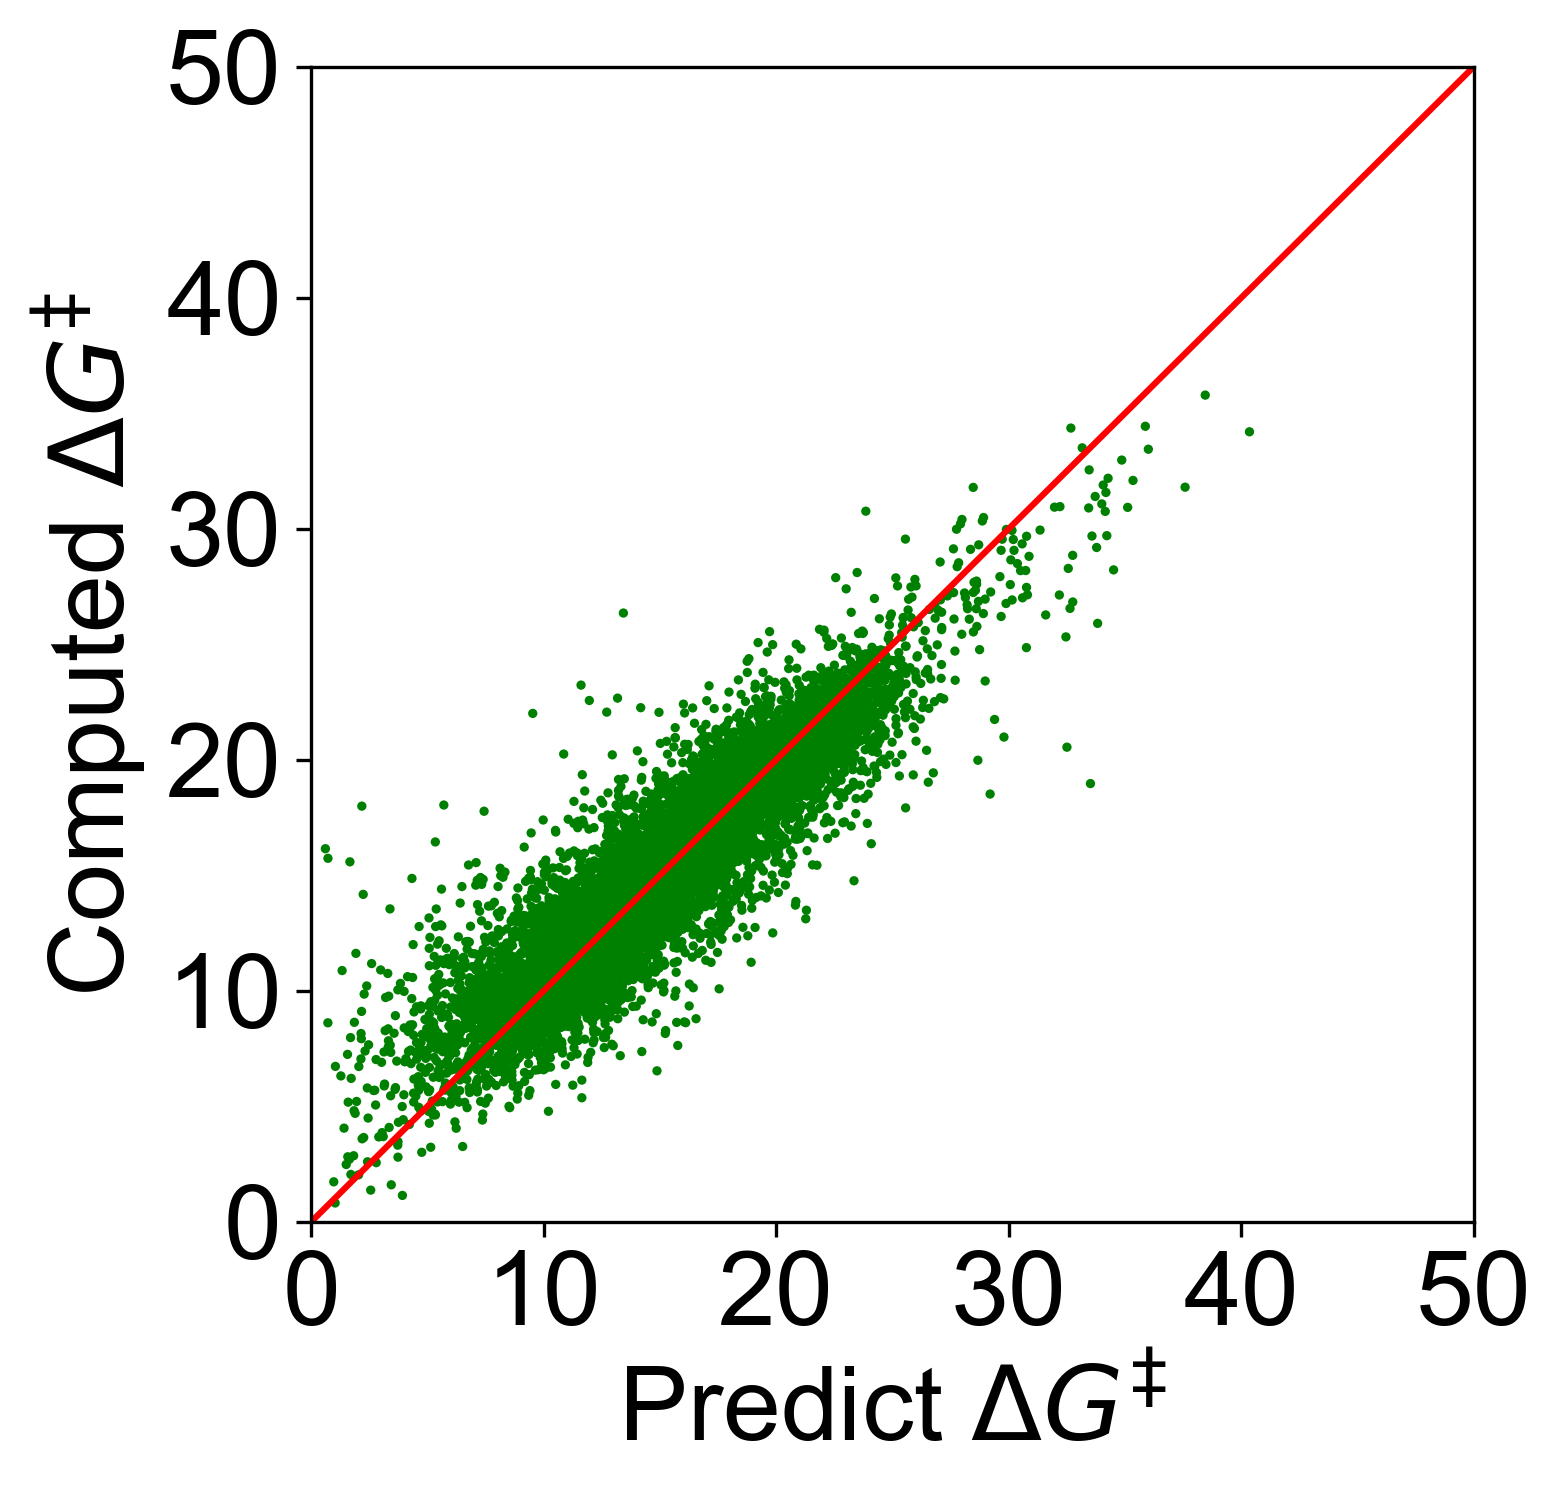

OOD by Nu_type


,OOD_axis,heldout_type,train_size,test_size,R2,MAE,MSE
0,Nu_type,Amine/Aryl N,3238,5742,0.680645,2.139584,8.477236
1,Nu_type,Phosphine,7182,1798,-0.010687,3.319996,20.271657
2,Nu_type,NHC,7540,1440,0.737577,1.785181,5.655264


Overall R2: 0.5893925643716351 MAE: 2.3190982988519147


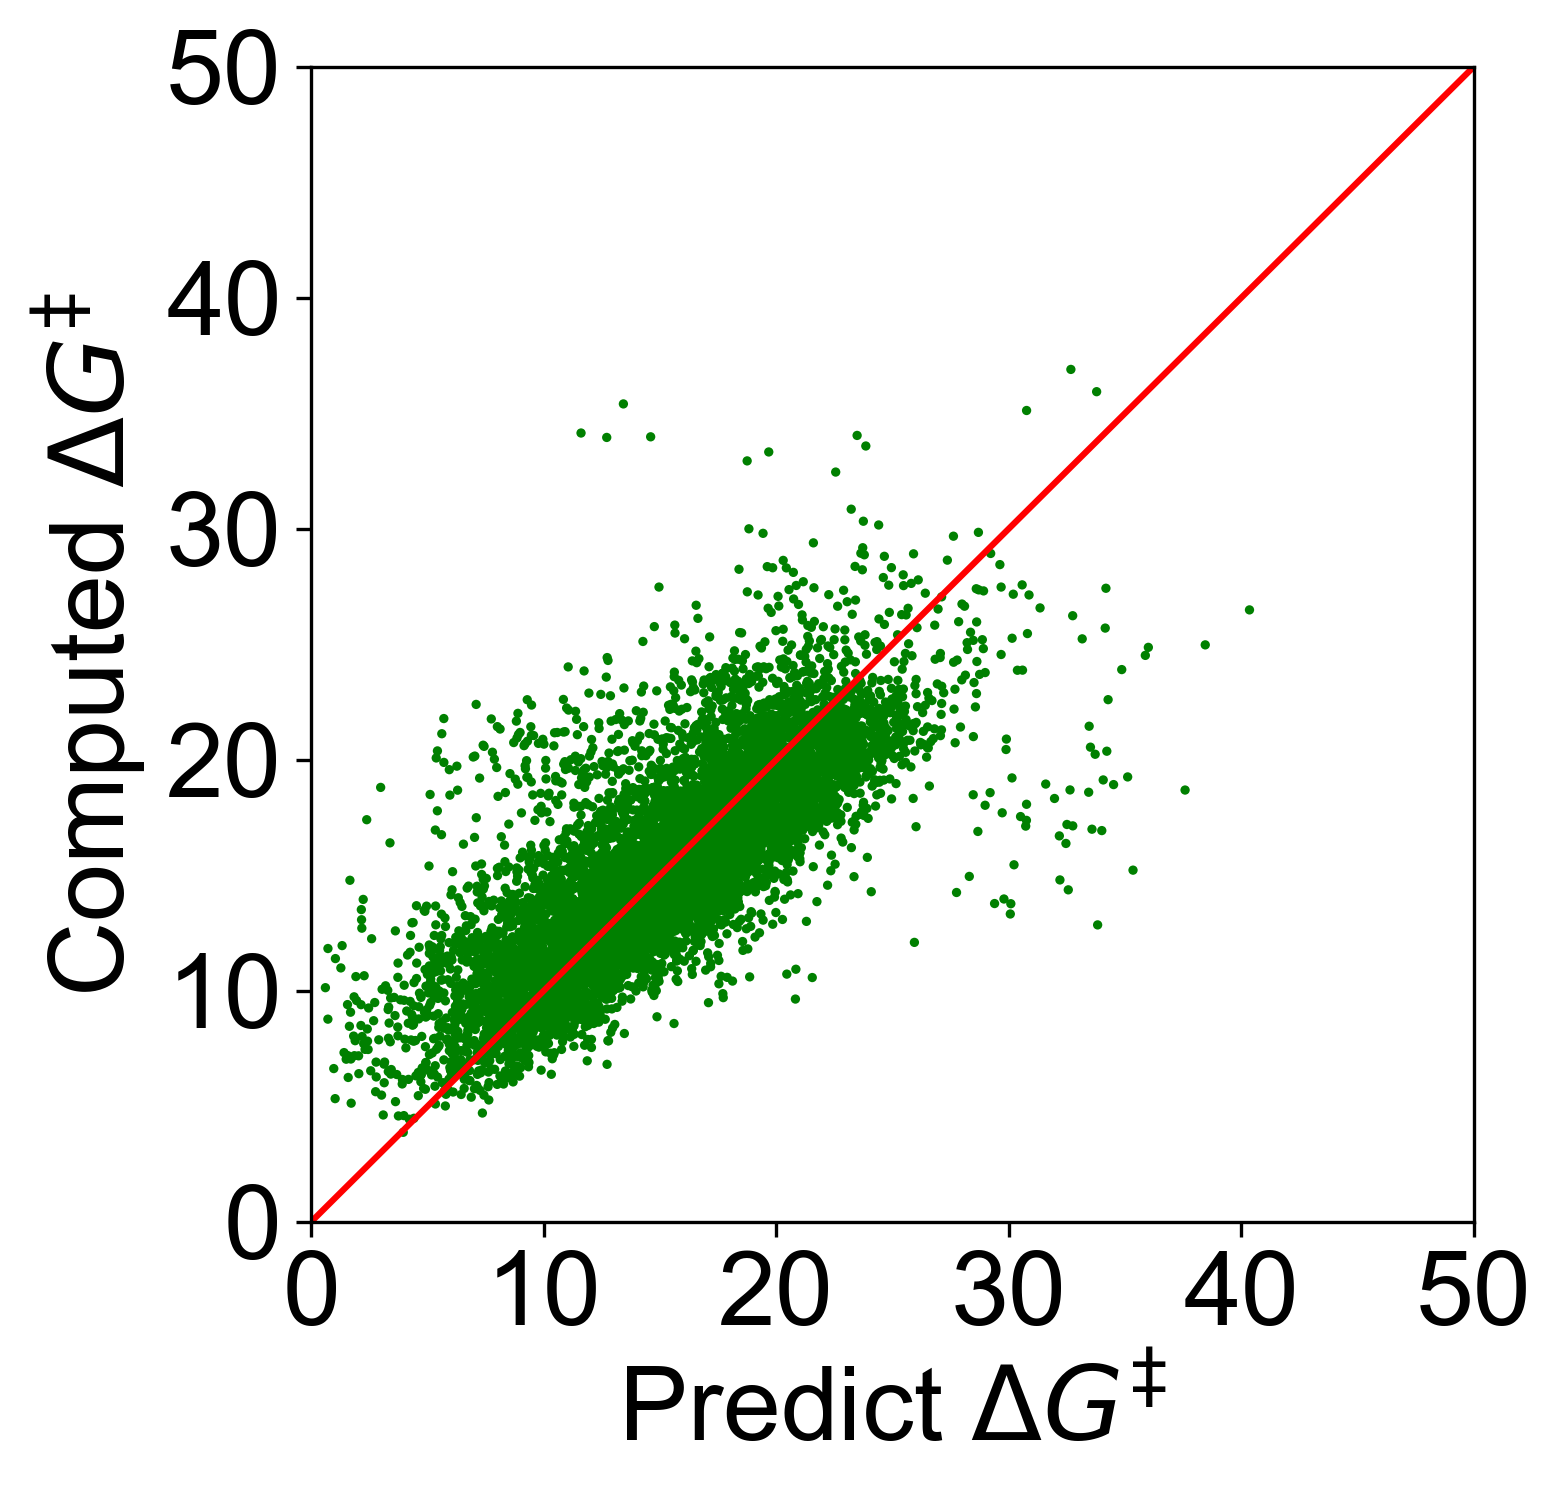

OOD by Cl_type


,OOD_axis,heldout_type,train_size,test_size,R2,MAE,MSE
0,Cl_type,CCl4,8769,211,0.897969,0.901404,1.633045
1,Cl_type,CCl3,7203,1777,0.854156,1.373599,3.243220
2,Cl_type,CCl2,6902,2078,0.863040,1.317386,3.102338
3,Cl_type,CCl,4066,4914,0.589727,2.504020,11.302098


Overall R2: 0.7002254288573803 MAE: 1.9680808663543787


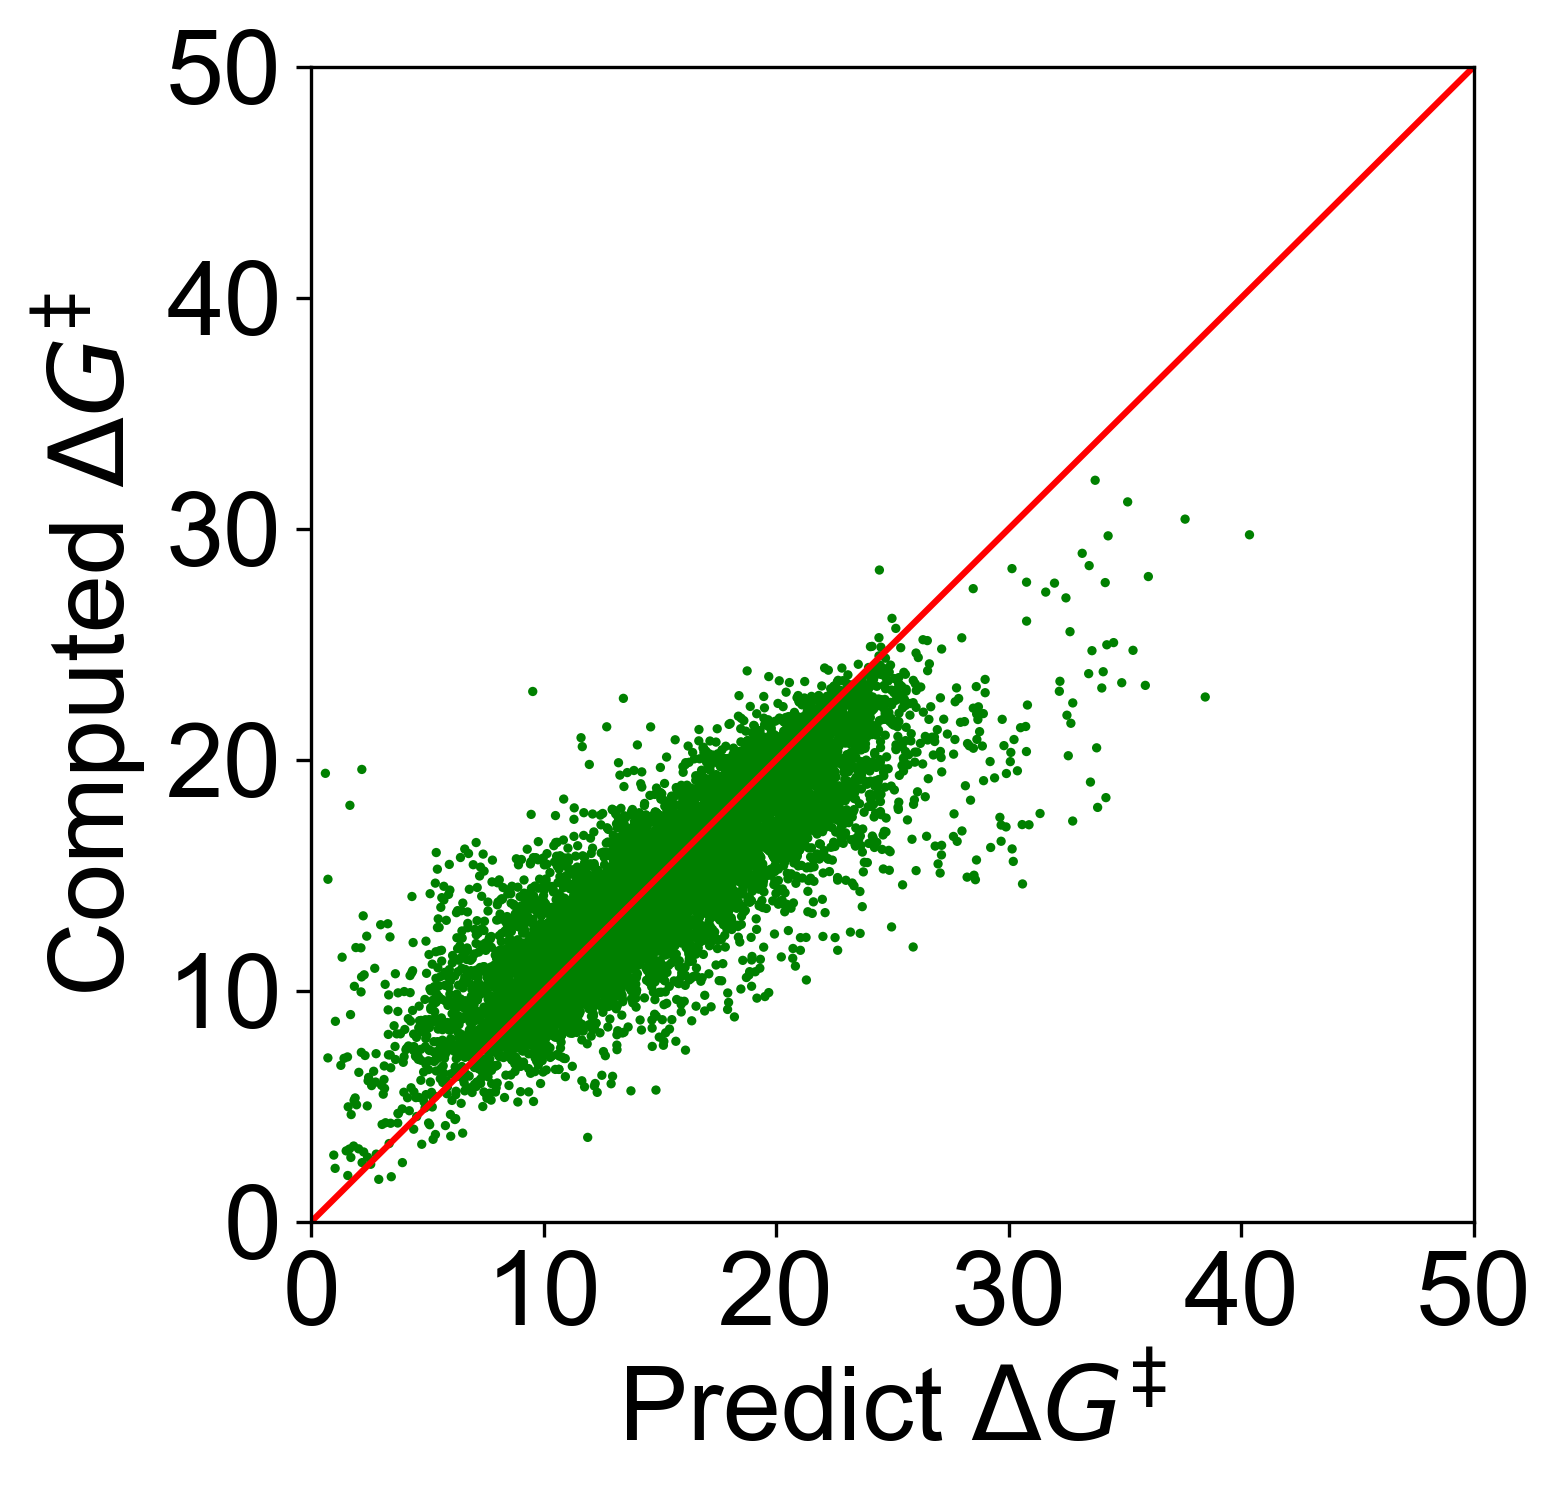

,OOD_axis,heldout_type,train_size,test_size,R2,MAE,MSE
0,B_type,R2BH,6570,2410,0.779905,1.844624,6.198643
1,B_type,RBH2,3200,5780,0.821235,1.547911,4.291551
2,B_type,BH3,8190,790,0.905611,1.145065,2.348189
3,Nu_type,Amine/Aryl N,3238,5742,0.680645,2.139584,8.477236
4,Nu_type,Phosphine,7182,1798,-0.010687,3.319996,20.271657
5,Nu_type,NHC,7540,1440,0.737577,1.785181,5.655264
6,Cl_type,CCl4,8769,211,0.897969,0.901404,1.633045
7,Cl_type,CCl3,7203,1777,0.854156,1.373599,3.243220
8,Cl_type,CCl2,6902,2078,0.863040,1.317386,3.102338
9,Cl_type,CCl,4066,4914,0.589727,2.504020,11.302098


In [51]:
def add_ood_type_columns(df):
    typed_df = df.copy()
    typed_df["B_type"] = typed_df["B_smiles"].map(get_boron_type)
    typed_df["Nu_type"] = typed_df["N_Index"].map(get_lb_type)
    typed_df["Cl_type"] = typed_df["Cl_smiles"].map(get_cl_substrate_type)
    return typed_df


def run_type_ood(
    typed_df,
    type_column,
    type_order=None,
    target_column=BARRIER_COLUMN,
    min_test_size=2,
):
    if type_order is None:
        type_order = sorted(typed_df[type_column].dropna().unique())

    result_rows = []
    pred_rows = []
    for heldout_type in type_order:
        test_df = typed_df.loc[typed_df[type_column] == heldout_type].reset_index(drop=True)
        train_df = typed_df.loc[typed_df[type_column] != heldout_type].reset_index(drop=True)
        if len(test_df) < min_test_size or len(train_df) == 0:
            continue

        train_X = dataframe_to_descriptors(
            train_df,
            B_N_des_map,
            Cl_des_map,
            duplicate_cl_ids=duplicate_Cl_id,
            show_progress=False,
            reaction_energy_column=REACTION_ENERGY_COLUMN,
        )
        test_X = dataframe_to_descriptors(
            test_df,
            B_N_des_map,
            Cl_des_map,
            duplicate_cl_ids=duplicate_Cl_id,
            show_progress=False,
            reaction_energy_column=REACTION_ENERGY_COLUMN,
        )
        train_y = train_df[target_column]
        test_y = test_df[target_column]

        model = CatBoostRegressor(
            iterations=10000,
            learning_rate=0.01,
            depth=6,
            verbose=0,
            random_state=0,
        )
        model.fit(train_X, train_y)
        y_pred = model.predict(test_X)

        result_rows.append({
            "OOD_axis": type_column,
            "heldout_type": heldout_type,
            "train_size": len(train_df),
            "test_size": len(test_df),
            "R2": r2_score(test_y, y_pred),
            "MAE": mean_absolute_error(test_y, y_pred),
            "MSE": mean_squared_error(test_y, y_pred),
        })
        pred_rows.extend(
            {
                "OOD_axis": type_column,
                "heldout_type": heldout_type,
                "y_true": y_true,
                "y_pred": pred,
            }
            for y_true, pred in zip(test_y.to_numpy(), y_pred)
        )

    return pd.DataFrame(result_rows), pd.DataFrame(pred_rows)


data_csv_typed = add_ood_type_columns(data_csv)
ood_type_counts = {
    "B_type": data_csv_typed["B_type"].value_counts().reindex(B_TYPE_ORDER).dropna().astype(int),
    "Nu_type": data_csv_typed["Nu_type"].value_counts().reindex(LB_TYPE_ORDER).dropna().astype(int),
    "Cl_type": data_csv_typed["Cl_type"].value_counts().reindex(CL_SUBSTRATE_TYPE_ORDER).dropna().astype(int),
}
for axis_name, counts in ood_type_counts.items():
    print(f"{axis_name} counts:")
    print(counts.to_string())
    print()


ood_type_results = {}
ood_type_predictions = {}
ood_type_configs = {
    "B_type": B_TYPE_ORDER,
    "Nu_type": LB_TYPE_ORDER,
    "Cl_type": CL_SUBSTRATE_TYPE_ORDER,
}

for type_column, type_order in ood_type_configs.items():
    result_df, pred_df = run_type_ood(
        data_csv_typed,
        type_column=type_column,
        type_order=type_order,
    )
    ood_type_results[type_column] = result_df
    ood_type_predictions[type_column] = pred_df

    print(f"OOD by {type_column}")
    display(result_df)
    if pred_df.empty:
        print(f"No valid OOD folds for {type_column}")
        continue
    print(
        "Overall R2:",
        r2_score(pred_df["y_true"], pred_df["y_pred"]),
        "MAE:",
        mean_absolute_error(pred_df["y_true"], pred_df["y_pred"]),
    )
    plot_scatter_with_metrics(
        pred_df["y_true"].to_numpy(),
        pred_df["y_pred"].to_numpy(),
        min_=0,
        max_=50,
    )


nonempty_ood_type_results = [
    result_df for result_df in ood_type_results.values() if not result_df.empty
]
if nonempty_ood_type_results:
    ood_type_summary = pd.concat(nonempty_ood_type_results, ignore_index=True)
else:
    ood_type_summary = pd.DataFrame()
display(ood_type_summary)


# Without DeltaG

In [52]:
all_X

array([[-3.19542931e+01,  1.10245000e+00, -1.62753119e-01, ...,
         8.69893000e-01, -1.41871127e-01, -1.33255900e+02],
       [-4.35224493e+01,  1.10074900e+00, -1.86918005e-01, ...,
         9.67023000e-01,  2.84736470e-03, -1.81855775e+02],
       [-2.56205066e+01,  1.10074900e+00, -1.86918005e-01, ...,
         9.07855000e-01, -6.19125052e-02, -2.05142300e+02],
       ...,
       [-2.49668620e+01,  9.52770000e-02,  2.26629946e-01, ...,
         7.39227000e-01,  5.74984184e-02, -2.12195400e+02],
       [-2.45504940e+01,  1.02232000e-01,  2.31353870e-01, ...,
         8.87077000e-01,  1.28059661e-02, -1.94838750e+02],
       [-3.07744101e+01,  6.95800000e-02,  2.44229511e-01, ...,
         6.66262000e-01,  4.45965935e-02, -1.68057050e+02]],
      shape=(8980, 18))

In [55]:
all_X_ = all_X[:,1:]
kf = KFold(n_splits=5, shuffle=True, random_state=0)
all_r2s = []
all_pred = np.zeros_like(y, dtype=float)

for train_ids, test_ids in kf.split(all_X_):
    model = CatBoostRegressor(
        iterations=10000,
        learning_rate=0.01,
        depth=6,
        verbose=0,
        random_state=0,
    )
    model.fit(all_X_[train_ids], y[train_ids])
    y_pred = model.predict(all_X_[test_ids])

    fold_r2 = r2_score(y[test_ids], y_pred)
    fold_mae = mean_absolute_error(y[test_ids], y_pred)
    fold_mse = mean_squared_error(y[test_ids], y_pred)
    print(f"R2: {fold_r2:.3f}, MAE: {fold_mae:.3f}, MSE: {fold_mse:.3f}")

    all_r2s.append(fold_r2)
    all_pred[test_ids] = y_pred

print(f"Mean of 5-Fold R2: {np.mean(all_r2s):.3f}")
print(f"Mean of 5-Fold MAE: {np.mean([mean_absolute_error(y[test_ids], all_pred[test_ids]) for train_ids, test_ids in kf.split(all_X)]):.3f}")


R2: 0.823, MAE: 1.480, MSE: 4.273
R2: 0.809, MAE: 1.592, MSE: 4.931
R2: 0.836, MAE: 1.483, MSE: 4.106
R2: 0.822, MAE: 1.526, MSE: 4.527
R2: 0.829, MAE: 1.534, MSE: 4.422
Mean of 5-Fold R2: 0.824
Mean of 5-Fold MAE: 1.523


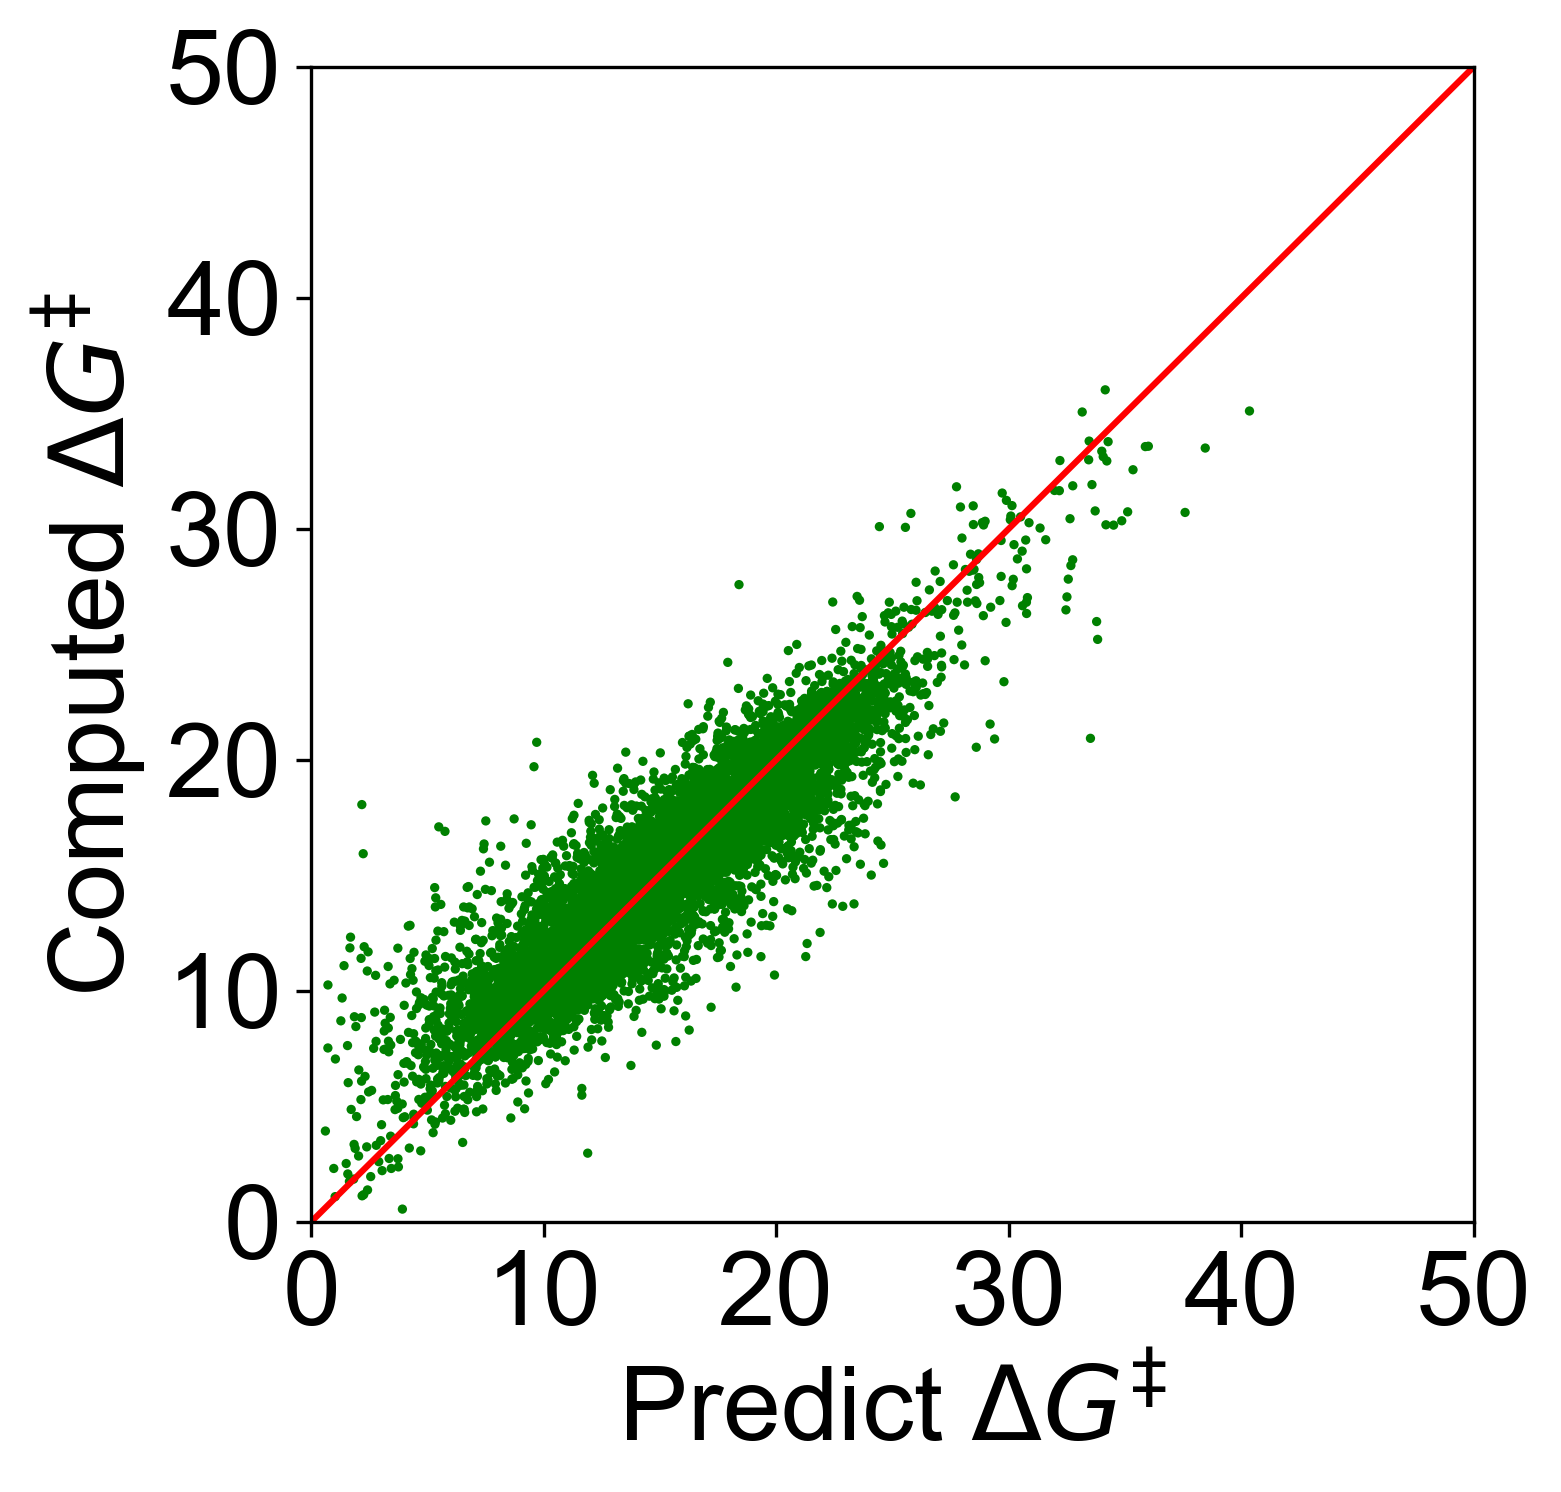

In [56]:
# Figure 6B
plot_scatter_with_metrics(
    y,
    all_pred,
    min_=0,
    max_=50,
    show=False,
)
plt.savefig(FIGURE_DIR / "Figure6B_model_validation_wo_deltaG.png", dpi=300, bbox_inches="tight")
plt.show()


# Five-fold cross-validation performance of the Model robustness after inclusion of thermodynamically disfavored transition states

In [15]:
pd.read_csv(TS_DATA_DIR / "result_filter_extended.csv")

,B_Index,N_Index,Cl_Index,conf_idxs_ts,TS_G,deltaG(kcal/mol),deltaGa(kcal/mol),B_Cl,C_Cl,G_energy_qharm,TS_G_qharm,deltaG_react_qharm,deltaG_qharm(kcal/mol),deltaGa_qharm(kcal/mol)
0,388,71,492,10,-2436.856731,20.231855,25.834702,2.252840,1.989601,-2437.072759,-2437.037561,-1.045917,-1.045917,22.086870
1,388,143,480,2,-1979.710016,20.036138,26.048686,2.229465,2.020106,-1979.829595,-1979.792276,-3.891084,-3.891084,23.418126
2,388,143,483,0,-1924.334580,2.549219,29.818869,2.161498,2.034505,-1924.459441,-1924.414890,3.506329,3.506329,27.956160
3,388,143,485,0,-1946.302429,-3.588484,46.673224,2.231557,2.040379,-1946.474187,-1946.435682,-2.814298,-2.814298,24.161998
4,388,143,492,11,-1794.912201,25.223994,30.928239,2.016620,2.036674,-1795.034761,-1794.989662,4.354755,4.354755,28.300123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,442,306,483,0,-1891.870377,38.661279,53.833081,2.051294,2.199843,-1892.059994,-1891.981025,38.375820,38.375820,49.553723
886,442,366,483,0,-2274.255987,35.692953,51.038541,2.095532,2.074113,-2274.446279,-2274.376770,32.250488,32.250488,43.617928
887,442,367,483,11,-2014.605769,37.820617,51.088967,2.159856,2.121024,-2014.830186,-2014.759710,34.492338,34.492338,44.224314
888,442,377,479,0,-2056.506749,36.361303,54.173826,2.015812,2.258816,-2056.748746,-2056.669316,35.769169,35.769169,49.843159


In [16]:
# Combined quantitative features used by the CatBoost barrier model.
data_csv = load_reaction_dataset(
    TS_DATA_DIR / "Borane_all.csv", use_qharm=USE_QHARM, db_path=DB_PATH
).dropna()
data_csv_2 = pd.read_csv(TS_DATA_DIR / "result_filter_extended.csv").dropna()
all_data_csv = pd.concat([data_csv, data_csv_2], ignore_index=True)
y = all_data_csv[BARRIER_COLUMN].to_numpy()
all_X = dataframe_to_descriptors(
    all_data_csv,
    B_N_des_map,
    Cl_des_map,
    duplicate_cl_ids=duplicate_Cl_id,
    reaction_energy_column=REACTION_ENERGY_COLUMN,
)
print(f"Feature matrix built from {DESCRIPTOR_VARIANT} descriptors: {all_X.shape}")


100%|██████████| 9870/9870 [00:00<00:00, 34986.00it/s]

Feature matrix built from DFT descriptors: (9870, 18)


In [17]:
all_X_ = all_X
kf = KFold(n_splits=5, shuffle=True, random_state=0)
all_r2s = []
all_pred = np.zeros_like(y, dtype=float)

for train_ids, test_ids in kf.split(all_X_):
    model = CatBoostRegressor(
        iterations=10000,
        learning_rate=0.01,
        depth=6,
        verbose=0,
        random_state=0,
    )
    model.fit(all_X_[train_ids], y[train_ids])
    y_pred = model.predict(all_X_[test_ids])

    fold_r2 = r2_score(y[test_ids], y_pred)
    fold_mae = mean_absolute_error(y[test_ids], y_pred)
    fold_mse = mean_squared_error(y[test_ids], y_pred)
    print(f"R2: {fold_r2:.3f}, MAE: {fold_mae:.3f}, MSE: {fold_mse:.3f}")

    all_r2s.append(fold_r2)
    all_pred[test_ids] = y_pred

print(f"Mean of 5-Fold R2: {np.mean(all_r2s):.3f}")
print(f"Mean of 5-Fold MAE: {np.mean([mean_absolute_error(y[test_ids], all_pred[test_ids]) for train_ids, test_ids in kf.split(all_X)]):.3f}")


R2: 0.948, MAE: 1.304, MSE: 3.215
R2: 0.938, MAE: 1.310, MSE: 3.351
R2: 0.947, MAE: 1.273, MSE: 3.264
R2: 0.944, MAE: 1.240, MSE: 2.940
R2: 0.944, MAE: 1.325, MSE: 3.431
Mean of 5-Fold R2: 0.944
Mean of 5-Fold MAE: 1.290


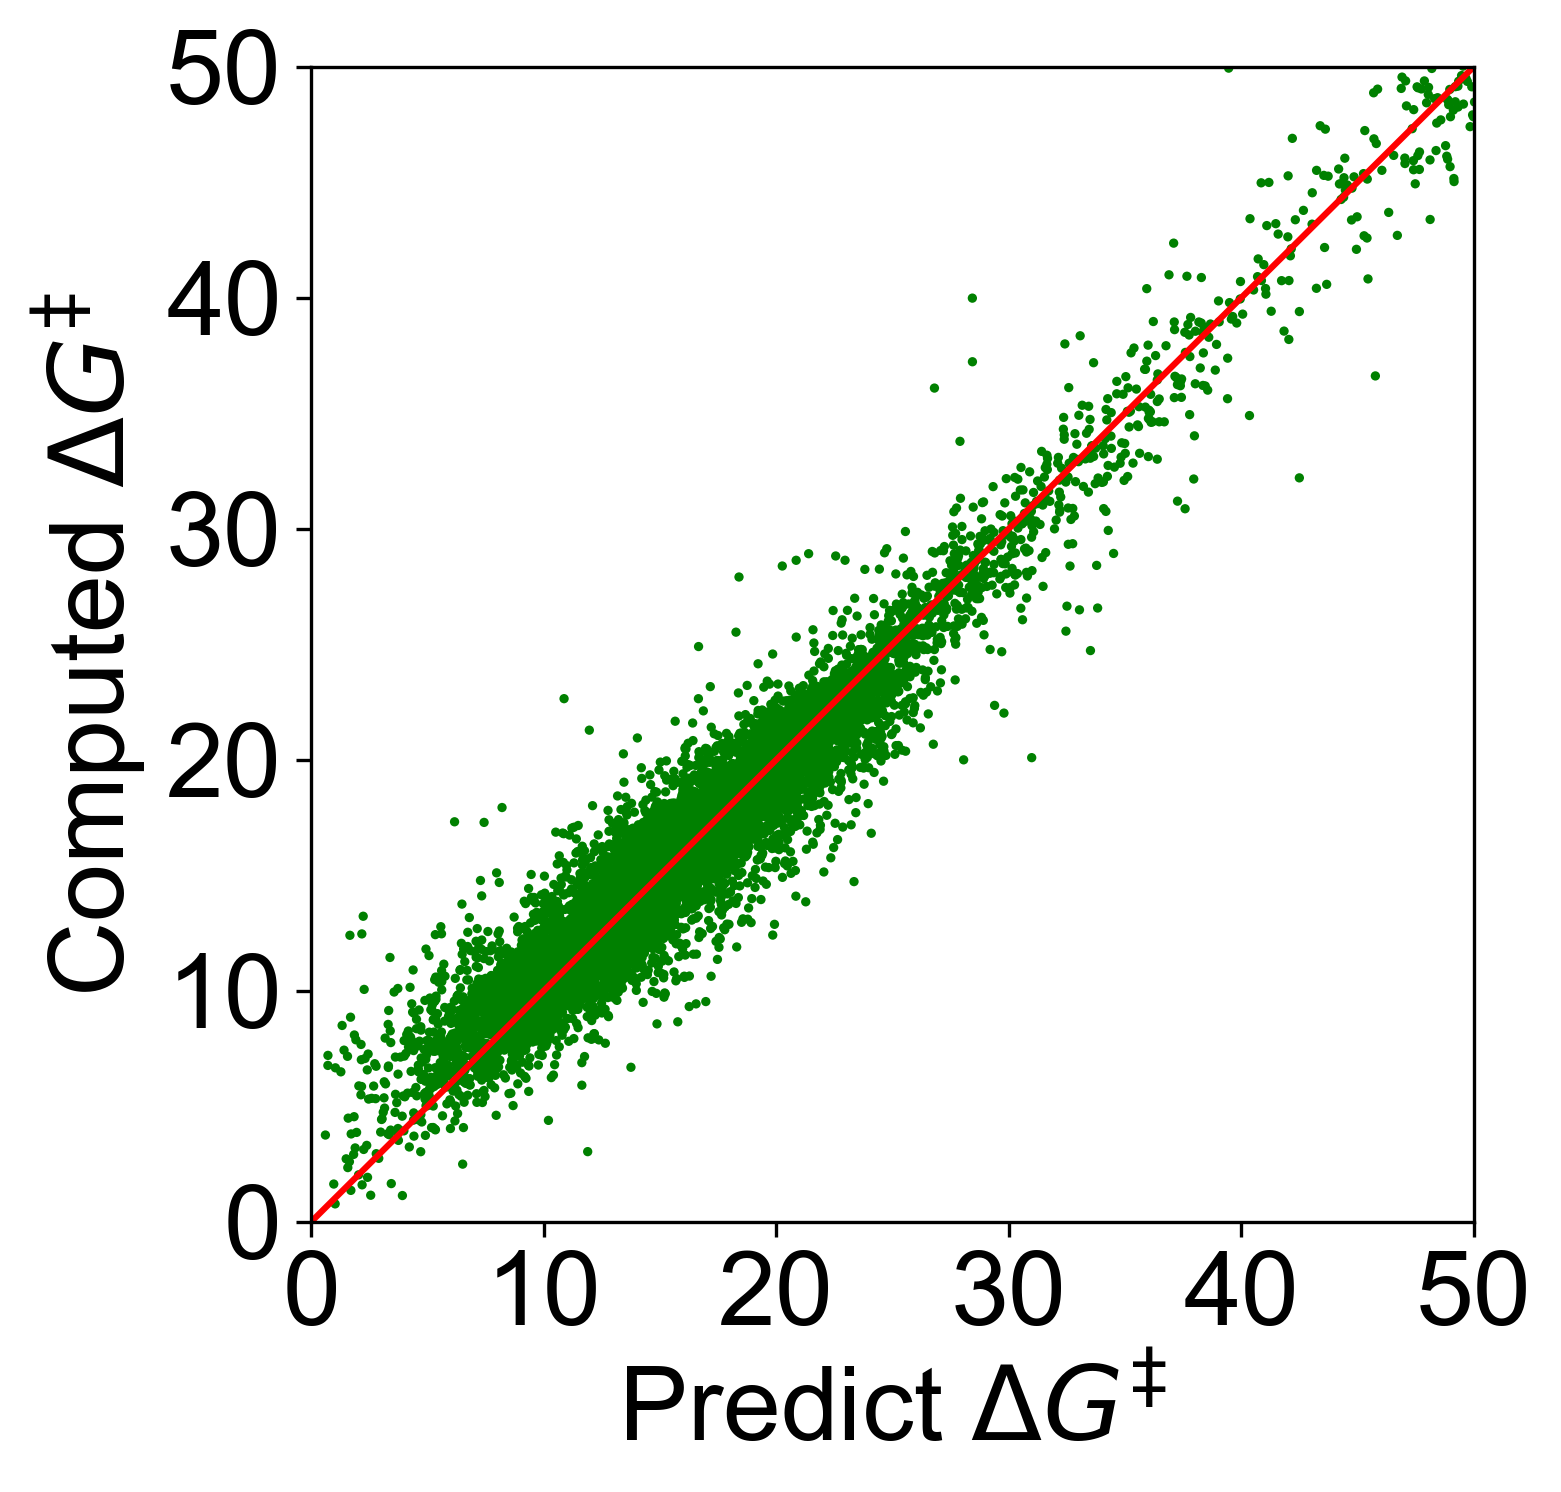

In [18]:
# Figure 6B
plot_scatter_with_metrics(
    y,
    all_pred,
    min_=0,
    max_=50,
    show=False,
)
plt.show()


In [11]:
model = CatBoostRegressor(
    iterations=10000,
    learning_rate=0.01,
    depth=6,
    verbose=0,
    random_state=0,
)
model.fit(all_X, y)
feature_importances = model.feature_importances_


In [12]:
des_name_std_sorted = [
    '$\\Delta G_{\\mathrm{rxn}}$',                 # deltaG
    'LB-B· $P^{\\mathrm{spin}}$',                  # B_N B_spin
    'LB-B· $q^{\\mathrm{B}}_{\\mathrm{H}}$',       # B_N B_Hirshfield_charge
    'LB-B· $d_{\\mathrm{LB-B}}$',                  # B_N B_N_dist
    'LB-B· $E_{\\mathrm{SOMO}}$',                  # B_N Alpha-HOMO
    'LB-B-Cl $q^{\\mathrm{B}}_{\\mathrm{H}}$',     # B_N_Cl B_Hirshfield_charge
    'LB-B-Cl $q^{\\mathrm{Cl}}_{\\mathrm{H}}$',    # B_N_Cl Cl_Hirshfield_charge
    'LB-B· $d_{\\mathrm{B-Cl}}$',                  # B_N_Cl N_Cl_dist
    'LB-B-Cl $E_{\\mathrm{LUMO}}$',                # B_N_Cl LUMO
    'LB-B-Cl $\\%V_{\\mathrm{bur}}$',              # B_N_Cl Bv6radius
    'Cl-C $q^{\\mathrm{Cl}}_{\\mathrm{H}}$',       # C_Cl Cl_Hirshfield_charge
    'Cl-C $q^{\\mathrm{C}}_{\\mathrm{H}}$',        # C_Cl C_Hirshfield_charge
    'Cl-C $d_{\\mathrm{Cl-C}}$',                   # C_Cl C_Cl_dist
    'Cl-C $E_{\\mathrm{LUMO}}$',                   # C_Cl LUMO
    'C_Cl $\\%V_{\\mathrm{bur}}$',                 # C_Cl Bv6radius
    'C· $P^{\\mathrm{spin}}$',                     # C C_spin
    'C· $q^{\\mathrm{C}}_{\\mathrm{H}}$',          # C C_Hirshfield_charge
    'C· $E_{\\mathrm{SOMO}}$'                      # C Alpha-HOMO
]

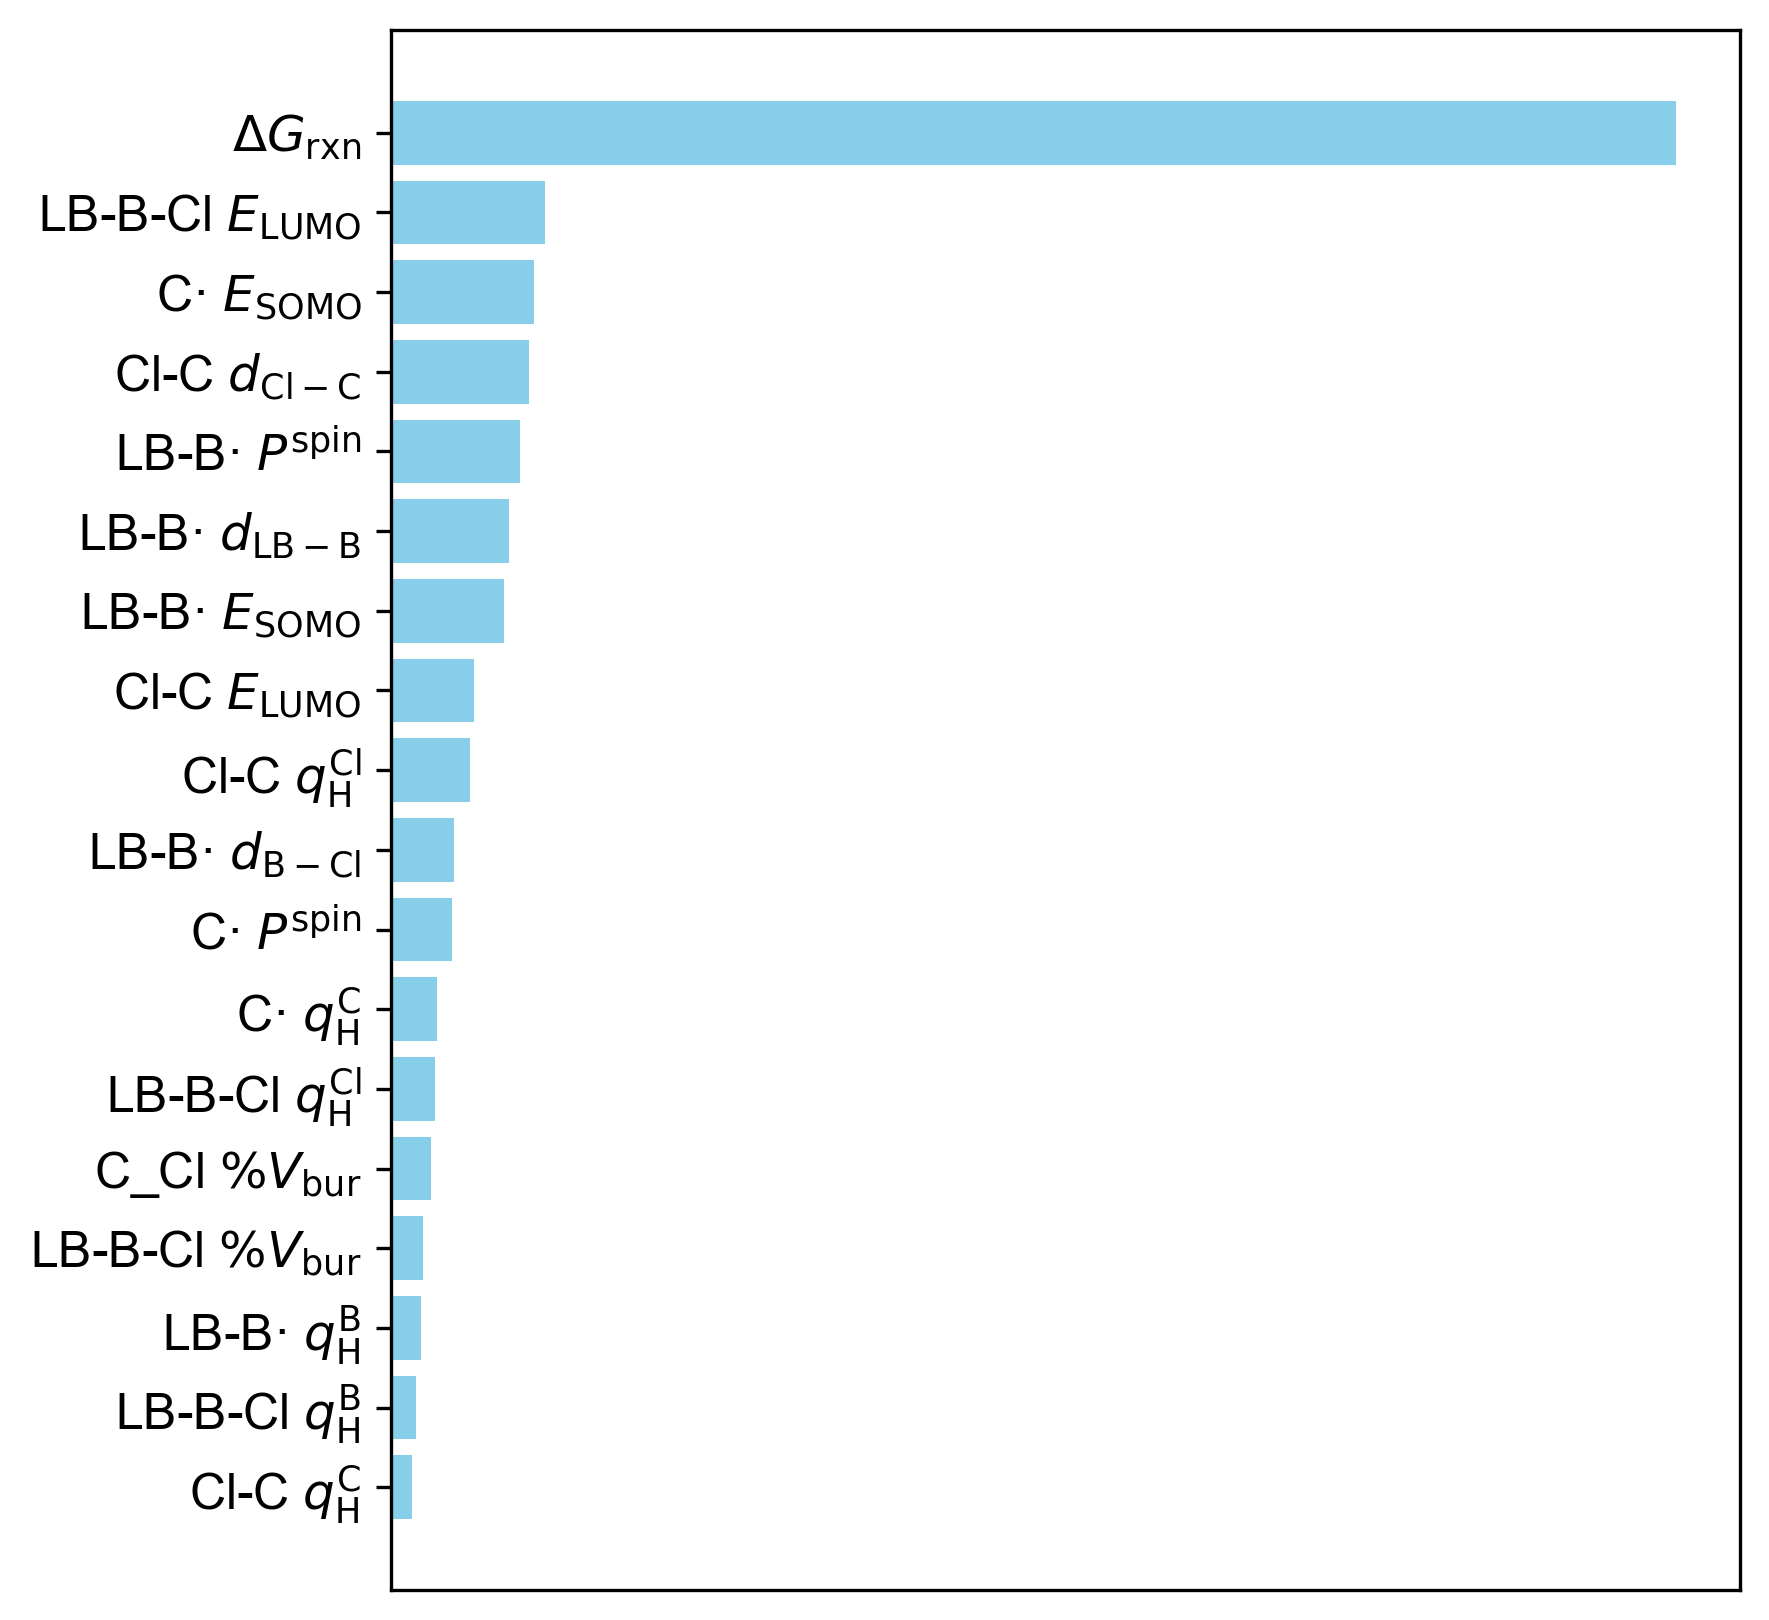

In [13]:
fig, ax = plt.subplots(figsize=(6, 5.5), dpi=300)
plt.rcParams["font.sans-serif"] = "Arial"
feature_order = np.argsort(feature_importances)
ax.barh(
    np.array(des_name_std_sorted)[feature_order],
    feature_importances[feature_order],
    color="skyblue",
)
ax.set_xticks([])
ax.tick_params(axis="y", labelsize=12)
fig.tight_layout()
# fig.savefig(FIGURE_DIR / "Figure6C_model_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()
